Final put together python notebook for Annular Aerospike nozzle analysis.

In [1]:
"""
NASA CEA Parameter Extractor
-----------------------------
Extracts: gamma (GAMMAs at exit), C*, At, Exit Velocity, Exit Mach
from a CEA output file with CHAMBER / THROAT / EXIT columns.\
HOW TO USE:
  1. Place this script in the same folder as your CEA output file.
  2. Edit FILE below.
  3. Run:  python cea_extractor.py
"""

import re

# ================================================================
#  USER SETTINGS
# ================================================================
FILE = "CEA(SL)F.txt"   # your CEA output filename
# ================================================================


def parse_blocks(filepath):
    with open(filepath, 'r') as f:
        content = f.read()

    blocks = re.split(r'(?=THEORETICAL ROCKET PERFORMANCE)', content)
    results = []

    for block in blocks:
        if 'THEORETICAL ROCKET PERFORMANCE' not in block:
            continue

        assumption = ('Equilibrium' if 'EQUILIBRIUM' in block
                      else 'Frozen' if 'FROZEN' in block else 'Unknown')

        def get_row(label):
            """Return list of floats for a data row, handling sci notation like 7.2388-2."""
            pattern = rf'{re.escape(label)}\s+([\d.E+\-]+(?:\s+[\d.E+\-]+)*)'
            m = re.search(pattern, block)
            if not m:
                return None
            raw = re.sub(r'(\d)([\+\-])(\d)', r'\1E\2\3', m.group(1))
            return [float(x) for x in raw.split()]

        # O/F
        of_m = re.search(r'O/F=\s*([\d.]+)', block)
        of   = float(of_m.group(1)) if of_m else None

        # Pc in PSIA
        pc_psia_m = re.search(r'Pin\s*=\s*([\d.]+)\s*PSIA', block)
        pc_psia   = float(pc_psia_m.group(1)) if pc_psia_m else None

        # Performance parameters block
        perf_block = re.search(r'PERFORMANCE PARAMETERS.*?(?=MASS FRACTIONS)', block, re.DOTALL)
        pb = perf_block.group(0) if perf_block else ''

        # C*
        cstar_m = re.search(r'CSTAR,\s*M/SEC\s+([\d.]+)', pb)
        cstar   = float(cstar_m.group(1)) if cstar_m else None

        # Isp at exit (second value)
        isp_m    = re.search(r'Isp,\s*M/SEC\s+([\d.]+)\s+([\d.]+)', pb)
        isp_exit = float(isp_m.group(2)) if isp_m else None

        # Column rows: [CHAMBER, THROAT, EXIT]
        gamma_row = get_row('GAMMAs')
        mach_row  = get_row('MACH NUMBER')
        son_row   = get_row('SON VEL,M/SEC')

        gamma_exit = gamma_row[2] if gamma_row and len(gamma_row) > 2 else None
        mach_exit  = mach_row[2]  if mach_row  and len(mach_row)  > 2 else None
        vel_exit   = (son_row[2] * mach_exit
                      if son_row and mach_exit and len(son_row) > 2 else None)

        results.append({
            'assumption': assumption,
            'pc_psia':    pc_psia,
            'of':         of,
            'cstar':      cstar,
            'gamma_exit': gamma_exit,
            'mach_exit':  mach_exit,
            'vel_exit':   vel_exit,
            'isp_exit':   isp_exit,
        })

    return results


def main():
    print(f"\nFile: {FILE}\n")
    results = parse_blocks(FILE)

    if not results:
        print("ERROR: No blocks found. Check your filename.")
        return

    for r in results:
        print("=" * 55)
        print(f"  {r['assumption'].upper()}  |  Pc = {r['pc_psia']} PSIA  |  O/F = {r['of']}")
        print("=" * 55)
        print(f"  C*             = {r['cstar']:.2f}  m/s")
        print(f"  Gamma (exit)   = {r['gamma_exit']:.4f}")
        print(f"  Mach (exit)    = {r['mach_exit']:.3f}")
        print(f"  Velocity (exit)= {r['vel_exit']:.2f}  m/s")
        print(f"  Isp (exit)     = {r['isp_exit']:.2f}  m/s")
        print()


if __name__ == '__main__':
    main()


File: CEA(SL)F.txt

  FROZEN  |  Pc = 377.1 PSIA  |  O/F = 5.0
  C*             = 2318.60  m/s
  Gamma (exit)   = 1.2416
  Mach (exit)    = 2.676
  Velocity (exit)= 3349.55  m/s
  Isp (exit)     = 3349.60  m/s




Reading: CEA(SL)F.txt  [frozen]

  CEA values used:
    Pc        = 377.1 PSIA  (2600014 Pa)
    O/F       = 5.0
    C*        = 2318.60 m/s
    Isp       = 3349.60 m/s
    Gamma     = 1.2416  (exit)
    Mach exit = 2.676
    Ae/At     = 4.1695  (from CEA)

  Geometry (At = 0.01338 m²):
    MDOT = 15.0040 kg/s
    At   = 133.8000 cm²   rt = 6.5261 cm  (2.5693 in)
    Ae   = 557.8791 cm²   re = 13.3259 cm

  Running MOC (15 lines)...

  Parabolic wall fit  y(x) = a·(x − b)² + c
  Normalised (/rt):
    y(x) = -0.0187·(x − 12.3903)² + 3.9501
  Dimensioned (cm):
    y(x) = -0.0029·(x − 80.8601)² + 25.7790


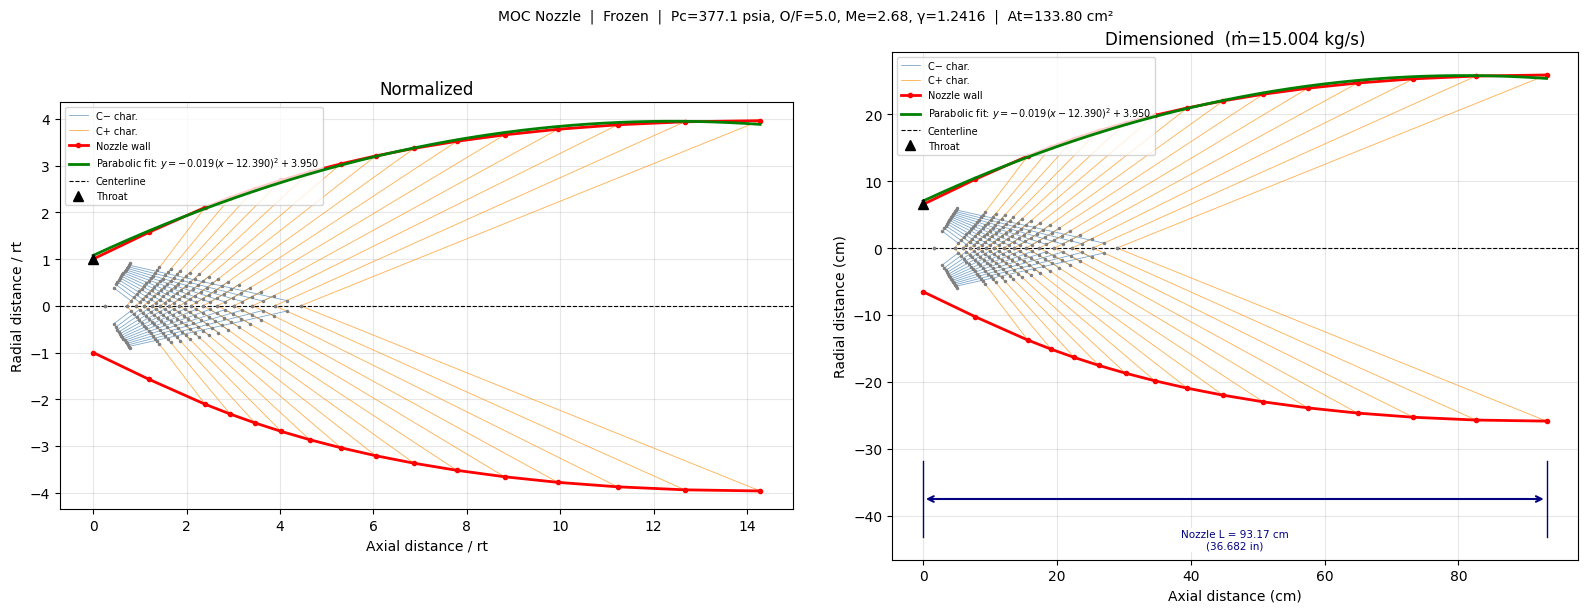

In [2]:
"""
MOC Minimum-Length Nozzle Contour — driven by NASA CEA output (Conventional bell) 
--------------------------------------------------------------
Reads gamma, Mach exit, C*, Pc, and Ae/At directly from your CEA file
via parse_blocks(), then computes and plots the nozzle wall contour via
Method of Characteristics, including C+ and C- characteristic lines.
Parabolic wall fit: y(x) = a*(x - b)^2 + c  via scipy curve_fit.
"""

import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar, curve_fit

# ================================================================
#  USER SETTINGS
# ================================================================
FILE       = "CEA(SL)F.txt"   # your CEA output filename
ASSUMPTION = "frozen"          # "equilibrium" or "frozen"
AT_KNOWN   = 0.01338           # m²  — physical throat area (e.g. 20.75 in² = 0.01338 m²)
                               #        not in CEA output, must be provided here
NUM_LINES  = 15                # MOC resolution (more = smoother, try 10–50)
# ================================================================


# ------------------------------------------------------------------
# 1. Parse CEA file  (from cea_extractor.py)
# ------------------------------------------------------------------
def parse_blocks(filepath):
    with open(filepath, 'r') as f:
        content = f.read()

    blocks = re.split(r'(?=THEORETICAL ROCKET PERFORMANCE)', content)
    results = []

    for block in blocks:
        if 'THEORETICAL ROCKET PERFORMANCE' not in block:
            continue

        assumption = ('Equilibrium' if 'EQUILIBRIUM' in block
                      else 'Frozen' if 'FROZEN' in block else 'Unknown')

        def get_row(label):
            """Return list of floats for a data row, handling sci notation like 7.2388-2."""
            pattern = rf'{re.escape(label)}\s+([\d.E+\-]+(?:\s+[\d.E+\-]+)*)'
            m = re.search(pattern, block)
            if not m:
                return None
            raw = re.sub(r'(\d)([\+\-])(\d)', r'\1E\2\3', m.group(1))
            return [float(x) for x in raw.split()]

        # O/F
        of_m = re.search(r'O/F=\s*([\d.]+)', block)
        of   = float(of_m.group(1)) if of_m else None

        # Pc in PSIA
        pc_psia_m = re.search(r'Pin\s*=\s*([\d.]+)\s*PSIA', block)
        pc_psia   = float(pc_psia_m.group(1)) if pc_psia_m else None

        # Performance parameters block
        perf_block = re.search(r'PERFORMANCE PARAMETERS.*?(?=MASS FRACTIONS)', block, re.DOTALL)
        pb = perf_block.group(0) if perf_block else ''

        # Ae/At (throat=1.0, exit=second value)
        aeat_m = re.search(r'Ae/At\s+([\d.]+)\s+([\d.]+)', pb)
        ae_at  = float(aeat_m.group(2)) if aeat_m else None

        # C*
        cstar_m = re.search(r'CSTAR,\s*M/SEC\s+([\d.]+)', pb)
        cstar   = float(cstar_m.group(1)) if cstar_m else None

        # Isp at exit (second value)
        isp_m    = re.search(r'Isp,\s*M/SEC\s+([\d.]+)\s+([\d.]+)', pb)
        isp_exit = float(isp_m.group(2)) if isp_m else None

        # Column rows: [CHAMBER, THROAT, EXIT]
        gamma_row = get_row('GAMMAs')
        mach_row  = get_row('MACH NUMBER')
        son_row   = get_row('SON VEL,M/SEC')

        gamma_exit = gamma_row[2] if gamma_row and len(gamma_row) > 2 else None
        mach_exit  = mach_row[2]  if mach_row  and len(mach_row)  > 2 else None
        vel_exit   = (son_row[2] * mach_exit
                      if son_row and mach_exit and len(son_row) > 2 else None)

        results.append({
            'assumption': assumption,
            'pc_psia':    pc_psia,
            'of':         of,
            'cstar':      cstar,
            'gamma_exit': gamma_exit,
            'mach_exit':  mach_exit,
            'vel_exit':   vel_exit,
            'ae_at':      ae_at,
            'isp_exit':   isp_exit,
        })

    return results


def select_block(results, assumption):
    """Return the result block matching the requested assumption."""
    target = assumption.strip().capitalize()
    for r in results:
        if r['assumption'].capitalize() == target:
            return r
    return None


# ------------------------------------------------------------------
# 2. Prandtl-Meyer functions
# ------------------------------------------------------------------
def prandtl_meyer(mach, gamma):
    return (
        np.sqrt((gamma + 1.) / (gamma - 1.)) *
        np.arctan(np.sqrt((gamma - 1.) * (mach**2 - 1.) / (gamma + 1.))) -
        np.arctan(np.sqrt(mach**2 - 1.))
    )

def solve_pm(mach, nu, gamma):
    return nu - prandtl_meyer(mach, gamma)


# ------------------------------------------------------------------
# 3. Parabola model  y(x) = a*(x - b)^2 + c
# ------------------------------------------------------------------
def parabola(x, a, b, c):
    return a * np.power(x - b, 2) + c


# ------------------------------------------------------------------
# 4. MOC kernel
# ------------------------------------------------------------------
def compute_moc(gamma, mach_exit, num_lines):
    angle_max = 0.5 * prandtl_meyer(mach_exit, gamma)

    idk_count = num_lines
    for idx in range(1, num_lines):
        for idy in range(idx, num_lines):
            idk_count += 1
        idk_count += 1
    num_points = idk_count + 1

    nus    = np.zeros(num_points)
    thetas = np.zeros(num_points)
    machs  = np.zeros(num_points)
    mus    = np.zeros(num_points)
    y      = np.zeros(num_points)
    x      = np.zeros(num_points)

    constant_minus = np.zeros(num_lines)
    constant_plus  = np.zeros(num_lines)

    c_minus_lines = []
    c_plus_lines  = []

    # ---- Initial expansion fan ----
    delta_theta0 = angle_max / num_lines
    nus[0]    = delta_theta0
    thetas[0] = delta_theta0
    sol = root_scalar(solve_pm, x0=1.1, bracket=[1.000001, 20], args=(nus[0], gamma))
    machs[0]  = sol.root
    mus[0]    = np.arcsin(1. / machs[0])
    constant_minus[0] = thetas[0] + nus[0]
    constant_plus[0]  = thetas[0] - nus[0]
    x[0] = -1. / np.tan(0.5*thetas[0] - 0.5*(np.pi/2. + mus[0]))
    y[0] = 0.

    delta_theta = (angle_max - delta_theta0) / (num_lines - 1)
    for idx in range(1, num_lines):
        thetas[idx] = thetas[idx-1] + delta_theta
        nus[idx]    = thetas[idx]
        sol = root_scalar(solve_pm, x0=1.1, bracket=[1.00001, 20], args=(nus[idx], gamma))
        machs[idx]  = sol.root
        mus[idx]    = np.arcsin(1. / machs[idx])
        constant_minus[idx] = thetas[idx] + nus[idx]

        dydx_p = np.tan(0.5*(thetas[idx-1]+thetas[idx]) + 0.5*(mus[idx-1]+mus[idx]))
        dydx_m = np.tan(thetas[idx] - mus[idx])
        y[idx]  = (dydx_p*(-1./dydx_m - x[idx-1]) + y[idx-1]) / (1 - dydx_p/dydx_m)
        x[idx]  = (y[idx] - 1.) / dydx_m

    # ---- Upper surface point ----
    idx = num_lines
    thetas[idx] = thetas[idx-1]
    nus[idx]    = nus[idx-1]
    machs[idx]  = machs[idx-1]
    mus[idx]    = mus[idx-1]
    dydx_m = np.tan(0.5*(angle_max + thetas[idx]))
    dydx_p = np.tan(0.5*(thetas[idx-1]+thetas[idx]) + 0.5*(mus[idx-1]+mus[idx]))
    y[idx]  = (dydx_p*(-x[idx-1] - 1./dydx_m) + y[idx-1]) / (1. - dydx_p/dydx_m)
    x[idx]  = (y[idx] - 1) / dydx_m

    # ---- Remaining characteristic lines ----
    idk = num_lines
    for idx in range(1, num_lines):
        c_minus = [idx]
        c_plus  = []

        for idy in range(idx, num_lines):
            idk += 1
            if idy == idx:
                thetas[idk] = 0
                nus[idk]    = constant_minus[idx]
                constant_plus[idx] = thetas[idk] - nus[idk]
                c_plus.append(idk)
            else:
                thetas[idk] = 0.5*(constant_minus[idy] + constant_plus[idx])
                nus[idk]    = 0.5*(constant_minus[idy] - constant_plus[idx])
                c_minus.append(idk)
                c_plus.append(idk)

            sol = root_scalar(solve_pm, x0=1.1, bracket=[1.0001, 20], args=(nus[idk], gamma))
            machs[idk] = sol.root
            mus[idk]   = np.arcsin(1. / machs[idk])

            idk_prev = idk - (num_lines - idx + 1)
            if idy == idx:
                y[idk] = 0.
                x[idk] = x[idk_prev] - y[idk_prev] / np.tan(thetas[idk_prev] - mus[idk_prev])
            else:
                dydx_p = np.tan(0.5*(thetas[idk-1]+thetas[idk]) + 0.5*(mus[idk-1]+mus[idk]))
                dydx_m = np.tan(0.5*(thetas[idk]+thetas[idk_prev]) - 0.5*(mus[idk]+mus[idk_prev]))
                y[idk] = (dydx_p*(-y[idk_prev]/dydx_m + x[idk_prev] - x[idk-1]) + y[idk-1]) / (1. - dydx_p/dydx_m)
                x[idk] = x[idk_prev] + (y[idk] - y[idk_prev]) / dydx_m

        # Wall point
        idk += 1
        thetas[idk] = thetas[idk-1]
        nus[idk]    = nus[idk-1]
        machs[idk]  = machs[idk-1]
        mus[idk]    = mus[idk-1]

        idk_prev = idk - (num_lines - idx + 1)
        dydx_m = np.tan(0.5*(thetas[idk_prev] + thetas[idk]))
        dydx_p = np.tan(0.5*(thetas[idk-1]+thetas[idk]) + 0.5*(mus[idk-1]+mus[idk]))
        y[idk] = (dydx_p*(-y[idk_prev]/dydx_m + x[idk_prev] - x[idk-1]) + y[idk-1]) / (1. - dydx_p/dydx_m)
        x[idk] = x[idk_prev] + (y[idk] - y[idk_prev]) / dydx_m

        c_plus.append(idk)
        c_minus_lines.append(c_minus)
        c_plus_lines.append(c_plus)

    return x, y, machs, c_minus_lines, c_plus_lines


# ------------------------------------------------------------------
# 5. Extract wall contour
# ------------------------------------------------------------------
def extract_wall(x, y, num_lines):
    wall_x = [0.0]
    wall_y = [1.0]
    idk = num_lines
    wall_x.append(x[idk])
    wall_y.append(y[idk])
    for idx in range(1, num_lines):
        for idy in range(idx, num_lines):
            idk += 1
        idk += 1
        wall_x.append(x[idk])
        wall_y.append(y[idk])
    return np.array(wall_x), np.array(wall_y)


# ------------------------------------------------------------------
# 6. Main
# ------------------------------------------------------------------
def main():
    print(f"\nReading: {FILE}  [{ASSUMPTION}]\n")
    results = parse_blocks(FILE)

    if not results:
        print(f"ERROR: No blocks found in {FILE}. Check your filename.")
        return

    cea = select_block(results, ASSUMPTION)
    if cea is None:
        found = [r['assumption'] for r in results]
        print(f"ERROR: Could not find '{ASSUMPTION}' block. Found: {found}")
        return

    # --- Pull all values from CEA output ---
    gamma     = cea['gamma_exit']
    mach_exit = cea['mach_exit']
    cstar     = cea['cstar']
    pc_psia   = cea['pc_psia']
    ae_at_cea = cea['ae_at']

    # --- Derive remaining quantities from CEA values + AT_KNOWN ---
    pc_pa = pc_psia * 6894.76                   # Pa
    mdot  = (AT_KNOWN * pc_pa) / cstar          # kg/s  from At·Pc/C*
    rt    = np.sqrt(AT_KNOWN / np.pi)           # m
    ae_m2 = AT_KNOWN * ae_at_cea                # m²

    print(f"  CEA values used:")
    print(f"    Pc        = {pc_psia} PSIA  ({pc_pa:.0f} Pa)")
    print(f"    O/F       = {cea['of']}")
    print(f"    C*        = {cstar:.2f} m/s")
    print(f"    Isp       = {cea['isp_exit']:.2f} m/s")
    print(f"    Gamma     = {gamma:.4f}  (exit)")
    print(f"    Mach exit = {mach_exit:.3f}")
    print(f"    Ae/At     = {ae_at_cea:.4f}  (from CEA)")

    print(f"\n  Geometry (At = {AT_KNOWN} m²):")
    print(f"    MDOT = {mdot:.4f} kg/s")
    print(f"    At   = {AT_KNOWN*1e4:.4f} cm²   rt = {rt*100:.4f} cm  ({rt*100/2.54:.4f} in)")
    print(f"    Ae   = {ae_m2*1e4:.4f} cm²   re = {np.sqrt(ae_m2/np.pi)*100:.4f} cm")

    print(f"\n  Running MOC ({NUM_LINES} lines)...")
    x_norm, y_norm, machs, c_minus_lines, c_plus_lines = \
        compute_moc(gamma, mach_exit, NUM_LINES)

    # --- Scale to real dimensions ---
    scale_cm = rt * 100          # normalised -> cm
    x_real   = x_norm * scale_cm
    y_real   = y_norm * scale_cm

    wall_xn, wall_yn = extract_wall(x_norm, y_norm, NUM_LINES)
    wall_xr = wall_xn * scale_cm
    wall_yr = wall_yn * scale_cm

    # --- Parabolic fit on normalised wall, then scale ---
    popt_n, _ = curve_fit(parabola, wall_xn, wall_yn,
                          p0=[-0.1, wall_xn[-1], wall_yn[-1]])
    a_n, b_n, c_n = popt_n

    xfit_n = np.linspace(0, np.max(wall_xn), 300)
    yfit_n = parabola(xfit_n, *popt_n)
    xfit_r = xfit_n * scale_cm
    yfit_r = yfit_n * scale_cm

    # Dimensioned parabola coefficients
    a_r = a_n / scale_cm
    b_r = b_n * scale_cm
    c_r = c_n * scale_cm

    print(f"\n  Parabolic wall fit  y(x) = a·(x − b)² + c")
    print(f"  Normalised (/rt):")
    print(f"    y(x) = {a_n:.4f}·(x − {b_n:.4f})² + {c_n:.4f}")
    print(f"  Dimensioned (cm):")
    print(f"    y(x) = {a_r:.4f}·(x − {b_r:.4f})² + {c_r:.4f}")

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), layout='constrained')
    fig.suptitle(
        f'MOC Nozzle  |  {ASSUMPTION.capitalize()}  |  '
        f'Pc={pc_psia} psia, O/F={cea["of"]}, Me={mach_exit:.2f}, γ={gamma:.4f}  |  '
        f'At={AT_KNOWN*1e4:.2f} cm²',
        fontsize=10
    )

    plot_configs = [
        (axes[0], x_norm, y_norm, wall_xn, wall_yn, xfit_n, yfit_n,
         1.0, 'Axial distance / rt', 'Normalized'),
        (axes[1], x_real, y_real, wall_xr, wall_yr, xfit_r, yfit_r,
         scale_cm, 'Axial distance (cm)', f'Dimensioned  (ṁ={mdot:.3f} kg/s)'),
    ]

    for ax, xd, yd, wxd, wyd, xfd, yfd, sc, xlabel, title in plot_configs:
        is_dim = (sc != 1.0)

        # C- characteristic lines
        for i, line in enumerate(c_minus_lines):
            lx = [xd[j] for j in line]
            ly = [yd[j] for j in line]
            ax.plot(lx,  ly, '-', color='steelblue', lw=0.6, alpha=0.7,
                    label='C− char.' if i == 0 else '')
            ax.plot(lx, [-v for v in ly], '-', color='steelblue', lw=0.6, alpha=0.7)

        # C+ characteristic lines
        for i, line in enumerate(c_plus_lines):
            lx = [xd[j] for j in line]
            ly = [yd[j] for j in line]
            ax.plot(lx,  ly, '-', color='darkorange', lw=0.6, alpha=0.7,
                    label='C+ char.' if i == 0 else '')
            ax.plot(lx, [-v for v in ly], '-', color='darkorange', lw=0.6, alpha=0.7)

        # Interior field points
        ax.plot(xd,  yd, 'o', ms=1.5, color='gray', zorder=3)
        ax.plot(xd, -yd, 'o', ms=1.5, color='gray', zorder=3)

        # MOC nozzle wall
        ax.plot(wxd,  wyd, 'r-o', ms=3, lw=2, zorder=5, label='Nozzle wall')
        ax.plot(wxd, -wyd, 'r-o', ms=3, lw=2, zorder=5)

        # Parabolic fit
        ax.plot(xfd,  yfd, 'g-', lw=2, zorder=6,
                label=fr'Parabolic fit: $y={a_n:.3f}(x-{b_n:.3f})^2+{c_n:.3f}$')

        # Centerline
        ax.axhline(0, color='k', lw=0.8, linestyle='--', label='Centerline')

        # Throat marker
        throat_r = 1.0 if not is_dim else rt * 100
        ax.plot(0, throat_r, 'k^', ms=7, zorder=7, label='Throat')

        # Dimension annotation on dimensioned plot
        if is_dim:
            nozzle_len  = wall_xr[-1]
            wall_top    = np.max(wall_yr)
            annot_y_bot = -wall_top * 1.45

            ax.annotate(
                '', xy=(nozzle_len, annot_y_bot), xytext=(0, annot_y_bot),
                arrowprops=dict(arrowstyle='<->', color='navy', lw=1.5)
            )
            ax.text(
                nozzle_len / 2, annot_y_bot * 1.12,
                f'Nozzle L = {nozzle_len:.2f} cm\n({nozzle_len/2.54:.3f} in)',
                ha='center', va='top', fontsize=7.5, color='navy',
                bbox=dict(fc='white', ec='none', pad=1)
            )
            ax.plot([0,          0         ], [annot_y_bot*0.85, annot_y_bot*1.15],
                    color='navy', lw=1)
            ax.plot([nozzle_len, nozzle_len], [annot_y_bot*0.85, annot_y_bot*1.15],
                    color='navy', lw=1)

        ax.set_xlabel(xlabel)
        ax.set_ylabel('Radial distance' + (' / rt' if not is_dim else ' (cm)'))
        ax.set_title(title)
        ax.set_aspect('equal', 'box')
        ax.legend(fontsize=7, loc='upper left')
        ax.grid(True, alpha=0.3)

    plt.show()


if __name__ == '__main__':
    main()


Reading: CEA(SL)F.txt  [frozen]

  CEA values used:
    Pc        = 377.1 PSIA  (2600014 Pa)
    O/F       = 5.0
    C*        = 2318.60 m/s
    Isp       = 3349.60 m/s
    Gamma     = 1.2416  (exit)
    Mach exit = 2.676
    Ae/At     = 4.1695  (from CEA)

  Geometry (At = 0.01338 m²):
    MDOT = 15.0040 kg/s
    At   = 133.8000 cm²   rt = 6.5261 cm  (2.5693 in)
    Ae   = 557.8791 cm²   re = 13.3259 cm

  Running MOC (15 lines)...

  Parabolic spike fit  y(x) = a·(x − b)² + c
  Normalised (/rt):
    y(x) = 0.0187·(x − 12.3903)² + 0.0129
  Dimensioned (cm):
    y(x) = 0.0029·(x − 80.8601)² + 0.0845


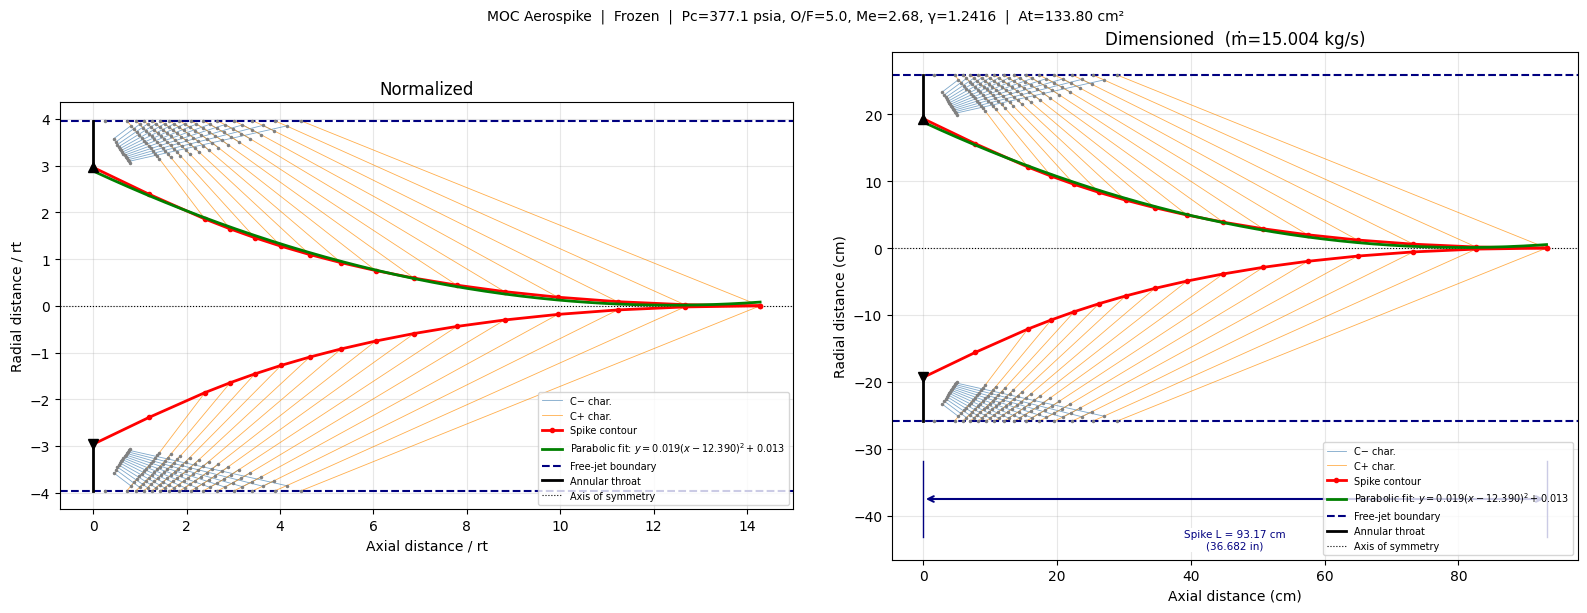

In [3]:
"""
MOC Aerospike Nozzle Contour — driven by NASA CEA output
---------------------------------------------------------
Reads gamma, Mach exit, C*, Pc, and Ae/At directly from your CEA file
via parse_blocks(), then computes and plots the aerospike spike contour via
Method of Characteristics, including C+ and C- characteristic lines.
Parabolic wall fit: y(x) = a*(x - b)^2 + c  via scipy curve_fit.

This is the Aerospike MOC for finding the contour of the nozzle.
The same equations apply just inverted so that the nozzle "wall"
runs towards itself and not away from itself.
The tip of the aerospike ends at the centerline of the conventional nozzle.
The base of the nozzle starts at the radial distance where the conventional
one would normally end. What is known as the free-jet boundary replaces
the outer wall.

The aerospike is the "flipped" version of the conventional nozzle:
  - The throat is at the OUTER radius (annular throat at top)
  - The spike wall is at the BOTTOM (centerline of the conventional nozzle)
  - Flow expands radially INWARD/downward along the spike surface
  - The free-jet boundary replaces the outer nozzle wall
"""

import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar, curve_fit

# ================================================================
#  USER SETTINGS
# ================================================================
FILE       = "CEA(SL)F.txt"   # your CEA output filename
ASSUMPTION = "frozen"          # "equilibrium" or "frozen"
AT_KNOWN   = 0.01338           # m²  — physical throat area (e.g. 20.75 in² = 0.01338 m²)
                               #        not in CEA output, must be provided here
NUM_LINES  = 15                # MOC resolution (more = smoother, try 10–50)
# ================================================================


# ------------------------------------------------------------------
# 1. Parse CEA file  (from cea_extractor.py)
# ------------------------------------------------------------------
def parse_blocks(filepath):
    with open(filepath, 'r') as f:
        content = f.read()

    blocks = re.split(r'(?=THEORETICAL ROCKET PERFORMANCE)', content)
    results = []

    for block in blocks:
        if 'THEORETICAL ROCKET PERFORMANCE' not in block:
            continue

        assumption = ('Equilibrium' if 'EQUILIBRIUM' in block
                      else 'Frozen' if 'FROZEN' in block else 'Unknown')

        def get_row(label):
            """Return list of floats for a data row, handling sci notation like 7.2388-2."""
            pattern = rf'{re.escape(label)}\s+([\d.E+\-]+(?:\s+[\d.E+\-]+)*)'
            m = re.search(pattern, block)
            if not m:
                return None
            raw = re.sub(r'(\d)([\+\-])(\d)', r'\1E\2\3', m.group(1))
            return [float(x) for x in raw.split()]

        # O/F
        of_m = re.search(r'O/F=\s*([\d.]+)', block)
        of   = float(of_m.group(1)) if of_m else None

        # Pc in PSIA
        pc_psia_m = re.search(r'Pin\s*=\s*([\d.]+)\s*PSIA', block)
        pc_psia   = float(pc_psia_m.group(1)) if pc_psia_m else None

        # Performance parameters block
        perf_block = re.search(r'PERFORMANCE PARAMETERS.*?(?=MASS FRACTIONS)', block, re.DOTALL)
        pb = perf_block.group(0) if perf_block else ''

        # Ae/At (throat=1.0, exit=second value)
        aeat_m = re.search(r'Ae/At\s+([\d.]+)\s+([\d.]+)', pb)
        ae_at  = float(aeat_m.group(2)) if aeat_m else None

        # C*
        cstar_m = re.search(r'CSTAR,\s*M/SEC\s+([\d.]+)', pb)
        cstar   = float(cstar_m.group(1)) if cstar_m else None

        # Isp at exit (second value)
        isp_m    = re.search(r'Isp,\s*M/SEC\s+([\d.]+)\s+([\d.]+)', pb)
        isp_exit = float(isp_m.group(2)) if isp_m else None

        # Column rows: [CHAMBER, THROAT, EXIT]
        gamma_row = get_row('GAMMAs')
        mach_row  = get_row('MACH NUMBER')
        son_row   = get_row('SON VEL,M/SEC')

        gamma_exit = gamma_row[2] if gamma_row and len(gamma_row) > 2 else None
        mach_exit  = mach_row[2]  if mach_row  and len(mach_row)  > 2 else None
        vel_exit   = (son_row[2] * mach_exit
                      if son_row and mach_exit and len(son_row) > 2 else None)

        results.append({
            'assumption': assumption,
            'pc_psia':    pc_psia,
            'of':         of,
            'cstar':      cstar,
            'gamma_exit': gamma_exit,
            'mach_exit':  mach_exit,
            'vel_exit':   vel_exit,
            'ae_at':      ae_at,
            'isp_exit':   isp_exit,
        })

    return results


def select_block(results, assumption):
    """Return the result block matching the requested assumption."""
    target = assumption.strip().capitalize()
    for r in results:
        if r['assumption'].capitalize() == target:
            return r
    return None


# ------------------------------------------------------------------
# 2. Prandtl-Meyer functions
# ------------------------------------------------------------------
def prandtl_meyer(mach, gamma):
    return (
        np.sqrt((gamma + 1.) / (gamma - 1.)) *
        np.arctan(np.sqrt((gamma - 1.) * (mach**2 - 1.) / (gamma + 1.))) -
        np.arctan(np.sqrt(mach**2 - 1.))
    )

def solve_pm(mach, nu, gamma):
    return nu - prandtl_meyer(mach, gamma)


# ------------------------------------------------------------------
# 3. Parabola model  y(x) = a*(x - b)^2 + c
# ------------------------------------------------------------------
def parabola(x, a, b, c):
    return a * np.power(x - b, 2) + c


# ------------------------------------------------------------------
# 4. MOC kernel — same math as conventional, connectivity identical
# ------------------------------------------------------------------
def compute_moc(gamma, mach_exit, num_lines):
    angle_max = 0.5 * prandtl_meyer(mach_exit, gamma)

    idk_count = num_lines
    for idx in range(1, num_lines):
        for idy in range(idx, num_lines):
            idk_count += 1
        idk_count += 1
    num_points = idk_count + 1

    nus    = np.zeros(num_points)
    thetas = np.zeros(num_points)
    machs  = np.zeros(num_points)
    mus    = np.zeros(num_points)
    y      = np.zeros(num_points)
    x      = np.zeros(num_points)

    constant_minus = np.zeros(num_lines)
    constant_plus  = np.zeros(num_lines)

    c_minus_lines = []
    c_plus_lines  = []

    # ---- Initial expansion fan ----
    delta_theta0 = angle_max / num_lines
    nus[0]    = delta_theta0
    thetas[0] = delta_theta0
    sol = root_scalar(solve_pm, x0=1.1, bracket=[1.000001, 20], args=(nus[0], gamma))
    machs[0]  = sol.root
    mus[0]    = np.arcsin(1. / machs[0])
    constant_minus[0] = thetas[0] + nus[0]
    constant_plus[0]  = thetas[0] - nus[0]
    x[0] = -1. / np.tan(0.5*thetas[0] - 0.5*(np.pi/2. + mus[0]))
    y[0] = 0.

    delta_theta = (angle_max - delta_theta0) / (num_lines - 1)
    for idx in range(1, num_lines):
        thetas[idx] = thetas[idx-1] + delta_theta
        nus[idx]    = thetas[idx]
        sol = root_scalar(solve_pm, x0=1.1, bracket=[1.00001, 20], args=(nus[idx], gamma))
        machs[idx]  = sol.root
        mus[idx]    = np.arcsin(1. / machs[idx])
        constant_minus[idx] = thetas[idx] + nus[idx]

        dydx_p = np.tan(0.5*(thetas[idx-1]+thetas[idx]) + 0.5*(mus[idx-1]+mus[idx]))
        dydx_m = np.tan(thetas[idx] - mus[idx])
        y[idx]  = (dydx_p*(-1./dydx_m - x[idx-1]) + y[idx-1]) / (1 - dydx_p/dydx_m)
        x[idx]  = (y[idx] - 1.) / dydx_m

    # ---- Upper surface point ----
    idx = num_lines
    thetas[idx] = thetas[idx-1]
    nus[idx]    = nus[idx-1]
    machs[idx]  = machs[idx-1]
    mus[idx]    = mus[idx-1]
    dydx_m = np.tan(0.5*(angle_max + thetas[idx]))
    dydx_p = np.tan(0.5*(thetas[idx-1]+thetas[idx]) + 0.5*(mus[idx-1]+mus[idx]))
    y[idx]  = (dydx_p*(-x[idx-1] - 1./dydx_m) + y[idx-1]) / (1. - dydx_p/dydx_m)
    x[idx]  = (y[idx] - 1) / dydx_m

    # ---- Remaining characteristic lines ----
    idk = num_lines
    for idx in range(1, num_lines):
        c_minus = [idx]
        c_plus  = []

        for idy in range(idx, num_lines):
            idk += 1
            if idy == idx:
                thetas[idk] = 0
                nus[idk]    = constant_minus[idx]
                constant_plus[idx] = thetas[idk] - nus[idk]
                c_plus.append(idk)
            else:
                thetas[idk] = 0.5*(constant_minus[idy] + constant_plus[idx])
                nus[idk]    = 0.5*(constant_minus[idy] - constant_plus[idx])
                c_minus.append(idk)
                c_plus.append(idk)

            sol = root_scalar(solve_pm, x0=1.1, bracket=[1.0001, 20], args=(nus[idk], gamma))
            machs[idk] = sol.root
            mus[idk]   = np.arcsin(1. / machs[idk])

            idk_prev = idk - (num_lines - idx + 1)
            if idy == idx:
                y[idk] = 0.
                x[idk] = x[idk_prev] - y[idk_prev] / np.tan(thetas[idk_prev] - mus[idk_prev])
            else:
                dydx_p = np.tan(0.5*(thetas[idk-1]+thetas[idk]) + 0.5*(mus[idk-1]+mus[idk]))
                dydx_m = np.tan(0.5*(thetas[idk]+thetas[idk_prev]) - 0.5*(mus[idk]+mus[idk_prev]))
                y[idk] = (dydx_p*(-y[idk_prev]/dydx_m + x[idk_prev] - x[idk-1]) + y[idk-1]) / (1. - dydx_p/dydx_m)
                x[idk] = x[idk_prev] + (y[idk] - y[idk_prev]) / dydx_m

        # Wall point
        idk += 1
        thetas[idk] = thetas[idk-1]
        nus[idk]    = nus[idk-1]
        machs[idk]  = machs[idk-1]
        mus[idk]    = mus[idk-1]

        idk_prev = idk - (num_lines - idx + 1)
        dydx_m = np.tan(0.5*(thetas[idk_prev] + thetas[idk]))
        dydx_p = np.tan(0.5*(thetas[idk-1]+thetas[idk]) + 0.5*(mus[idk-1]+mus[idk]))
        y[idk] = (dydx_p*(-y[idk_prev]/dydx_m + x[idk_prev] - x[idk-1]) + y[idk-1]) / (1. - dydx_p/dydx_m)
        x[idk] = x[idk_prev] + (y[idk] - y[idk_prev]) / dydx_m

        c_plus.append(idk)
        c_minus_lines.append(c_minus)
        c_plus_lines.append(c_plus)

    return x, y, machs, c_minus_lines, c_plus_lines


# ------------------------------------------------------------------
# 5. Extract wall (spike) contour
# ------------------------------------------------------------------
def extract_wall(x, y, num_lines):
    wall_x = [0.0]
    wall_y = [1.0]
    idk = num_lines
    wall_x.append(x[idk])
    wall_y.append(y[idk])
    for idx in range(1, num_lines):
        for idy in range(idx, num_lines):
            idk += 1
        idk += 1
        wall_x.append(x[idk])
        wall_y.append(y[idk])
    return np.array(wall_x), np.array(wall_y)


# ------------------------------------------------------------------
# 6. Flip coordinates for aerospike:
#    Conventional:  throat at y=1 (top wall), centerline at y=0
#    Aerospike:     throat at r=rt (outer annulus), spike tip at r=0
#
#    Flip:  y_spike = y_max - y_conv  (invert radial axis)
#           x_spike = x_conv          (axial stays the same)
#
#    This maps:
#      conventional wall  (y = high)  → spike tip  (r = low)
#      conventional centerline (y=0)  → free-jet boundary (r = high)
# ------------------------------------------------------------------
def flip_to_aerospike(x, y, y_max):
    return x.copy(), y_max - y


# ------------------------------------------------------------------
# 7. Main
# ------------------------------------------------------------------
def main():
    print(f"\nReading: {FILE}  [{ASSUMPTION}]\n")
    results = parse_blocks(FILE)

    if not results:
        print(f"ERROR: No blocks found in {FILE}. Check your filename.")
        return

    cea = select_block(results, ASSUMPTION)
    if cea is None:
        found = [r['assumption'] for r in results]
        print(f"ERROR: Could not find '{ASSUMPTION}' block. Found: {found}")
        return

    # --- Pull all values from CEA output ---
    gamma     = cea['gamma_exit']
    mach_exit = cea['mach_exit']
    cstar     = cea['cstar']
    pc_psia   = cea['pc_psia']
    ae_at_cea = cea['ae_at']

    # --- Derive remaining quantities from CEA values + AT_KNOWN ---
    pc_pa = pc_psia * 6894.76                   # Pa
    mdot  = (AT_KNOWN * pc_pa) / cstar          # kg/s  from At·Pc/C*
    rt    = np.sqrt(AT_KNOWN / np.pi)           # m
    ae_m2 = AT_KNOWN * ae_at_cea                # m²

    print(f"  CEA values used:")
    print(f"    Pc        = {pc_psia} PSIA  ({pc_pa:.0f} Pa)")
    print(f"    O/F       = {cea['of']}")
    print(f"    C*        = {cstar:.2f} m/s")
    print(f"    Isp       = {cea['isp_exit']:.2f} m/s")
    print(f"    Gamma     = {gamma:.4f}  (exit)")
    print(f"    Mach exit = {mach_exit:.3f}")
    print(f"    Ae/At     = {ae_at_cea:.4f}  (from CEA)")

    print(f"\n  Geometry (At = {AT_KNOWN} m²):")
    print(f"    MDOT = {mdot:.4f} kg/s")
    print(f"    At   = {AT_KNOWN*1e4:.4f} cm²   rt = {rt*100:.4f} cm  ({rt*100/2.54:.4f} in)")
    print(f"    Ae   = {ae_m2*1e4:.4f} cm²   re = {np.sqrt(ae_m2/np.pi)*100:.4f} cm")

    print(f"\n  Running MOC ({NUM_LINES} lines)...")
    x_norm, y_norm, machs, c_minus_lines, c_plus_lines = \
        compute_moc(gamma, mach_exit, NUM_LINES)

    y_max_norm = y_norm.max()

    # --- Normalized aerospike coords ---
    xa_norm, ya_norm   = flip_to_aerospike(x_norm, y_norm, y_max_norm)
    wall_xn, wall_yn   = extract_wall(x_norm, y_norm, NUM_LINES)
    spike_xn, spike_yn = flip_to_aerospike(wall_xn, wall_yn, y_max_norm)
    freejet_yn_norm    = y_max_norm

    # --- Scale to real dimensions (cm) ---
    scale_cm   = rt * 100
    xa_real    = xa_norm  * scale_cm
    ya_real    = ya_norm  * scale_cm
    spike_xr   = spike_xn * scale_cm
    spike_yr   = spike_yn * scale_cm
    freejet_yr = freejet_yn_norm * scale_cm

    # --- Parabolic fit on spike contour ---
    popt_n, _ = curve_fit(parabola, spike_xn, spike_yn,
                          p0=[0.1, spike_xn[-1], spike_yn[-1]])
    a_n, b_n, c_n = popt_n

    xfit_n = np.linspace(0, np.max(spike_xn), 300)
    yfit_n = parabola(xfit_n, *popt_n)

    a_r = a_n / scale_cm
    b_r = b_n * scale_cm
    c_r = c_n * scale_cm

    xfit_r = xfit_n * scale_cm
    yfit_r = yfit_n * scale_cm

    print(f"\n  Parabolic spike fit  y(x) = a·(x − b)² + c")
    print(f"  Normalised (/rt):")
    print(f"    y(x) = {a_n:.4f}·(x − {b_n:.4f})² + {c_n:.4f}")
    print(f"  Dimensioned (cm):")
    print(f"    y(x) = {a_r:.4f}·(x − {b_r:.4f})² + {c_r:.4f}")

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), layout='constrained')
    fig.suptitle(
        f'MOC Aerospike  |  {ASSUMPTION.capitalize()}  |  '
        f'Pc={pc_psia} psia, O/F={cea["of"]}, Me={mach_exit:.2f}, γ={gamma:.4f}  |  '
        f'At={AT_KNOWN*1e4:.2f} cm²',
        fontsize=10
    )

    plot_configs = [
        (axes[0], xa_norm, ya_norm, spike_xn, spike_yn, xfit_n, yfit_n,
         freejet_yn_norm, 1.0, 'Axial distance / rt', 'Normalized'),
        (axes[1], xa_real, ya_real, spike_xr, spike_yr, xfit_r, yfit_r,
         freejet_yr, scale_cm, 'Axial distance (cm)',
         f'Dimensioned  (ṁ={mdot:.3f} kg/s)'),
    ]

    for ax, xd, yd, sxd, syd, xfd, yfd, fj_y, sc, xlabel, title in plot_configs:
        is_dim = (sc != 1.0)

        # C- characteristic lines
        for i, line in enumerate(c_minus_lines):
            lx = [xd[j] for j in line]
            ly = [yd[j] for j in line]
            ax.plot(lx,  ly, '-', color='steelblue', lw=0.6, alpha=0.7,
                    label='C− char.' if i == 0 else '')
            ax.plot(lx, [-v for v in ly], '-', color='steelblue', lw=0.6, alpha=0.7)

        # C+ characteristic lines
        for i, line in enumerate(c_plus_lines):
            lx = [xd[j] for j in line]
            ly = [yd[j] for j in line]
            ax.plot(lx,  ly, '-', color='darkorange', lw=0.6, alpha=0.7,
                    label='C+ char.' if i == 0 else '')
            ax.plot(lx, [-v for v in ly], '-', color='darkorange', lw=0.6, alpha=0.7)

        # Interior field points
        ax.plot(xd,  yd, 'o', ms=1.5, color='gray', zorder=3)
        ax.plot(xd, -yd, 'o', ms=1.5, color='gray', zorder=3)

        # Spike contour
        ax.plot(sxd,  syd, 'r-o', ms=3, lw=2, zorder=5, label='Spike contour')
        ax.plot(sxd, -syd, 'r-o', ms=3, lw=2, zorder=5)

        # Parabolic fit overlay
        ax.plot(xfd,  yfd, 'g-', lw=2, zorder=6,
                label=fr'Parabolic fit: $y={a_n:.3f}(x-{b_n:.3f})^2+{c_n:.3f}$')

        # Free-jet boundary
        ax.axhline( fj_y, color='navy', lw=1.5, linestyle='--', label='Free-jet boundary')
        ax.axhline(-fj_y, color='navy', lw=1.5, linestyle='--')

        # Annular throat at x=0
        ax.plot([0, 0], [ syd[0],  fj_y], 'k-', lw=2, zorder=6, label='Annular throat')
        ax.plot([0, 0], [-syd[0], -fj_y], 'k-', lw=2, zorder=6)
        ax.plot(0,  syd[0], 'k^', ms=7, zorder=7)
        ax.plot(0, -syd[0], 'kv', ms=7, zorder=7)

        # Axis of symmetry
        ax.axhline(0, color='k', lw=0.8, linestyle=':', label='Axis of symmetry')

        # Dimension annotation on dimensioned plot
        if is_dim:
            spike_len   = spike_xr[-1]
            annot_y_bot = -fj_y * 1.45

            ax.annotate(
                '', xy=(spike_len, annot_y_bot), xytext=(0, annot_y_bot),
                arrowprops=dict(arrowstyle='<->', color='navy', lw=1.5)
            )
            ax.text(
                spike_len / 2, annot_y_bot * 1.12,
                f'Spike L = {spike_len:.2f} cm\n({spike_len/2.54:.3f} in)',
                ha='center', va='top', fontsize=7.5, color='navy',
                bbox=dict(fc='white', ec='none', pad=1)
            )
            ax.plot([0,         0        ], [annot_y_bot*0.85, annot_y_bot*1.15],
                    color='navy', lw=1)
            ax.plot([spike_len, spike_len], [annot_y_bot*0.85, annot_y_bot*1.15],
                    color='navy', lw=1)

        ax.set_xlabel(xlabel)
        ax.set_ylabel('Radial distance' + (' / rt' if not is_dim else ' (cm)'))
        ax.set_title(title)
        ax.set_aspect('equal', 'box')
        ax.legend(fontsize=7, loc='lower right')
        ax.grid(True, alpha=0.3)

    plt.show()


if __name__ == '__main__':
    main()

  NOZZLE THRUST COEFFICIENT (C_F) INTEGRATION ANALYSIS

  CEA values used (frozen):
    gamma (γ)          = 1.2416
    Pc                 = 2.6000 MPa  (377.1 PSIA)
    Pe_bell (fixed)    = 105653.16 Pa
    Ae/At              = 4.1695
    O/F                = 5.0
    C*                 = 2318.60 m/s
    Isp                = 3349.60 m/s
    At                 = 0.01338 m²
    MDOT               = 15.0040 kg/s
    Altitude range     = 0 – 60 km
    Integration steps  = 5000

  Altitude (km)    Pa (kPa)       CF_bell        CF_spike      
  ----------------------------------------------------------
  0.0              101.325        1.44031        1.44007       
  6.7              43.034         1.53379        1.56058       
  13.3             15.691         1.57764        1.67059       
  20.0             5.478          1.59402        1.75906       
  26.7             2.290          1.59913        1.81734       
  33.3             1.631          1.60019        1.83706       
  40.0      

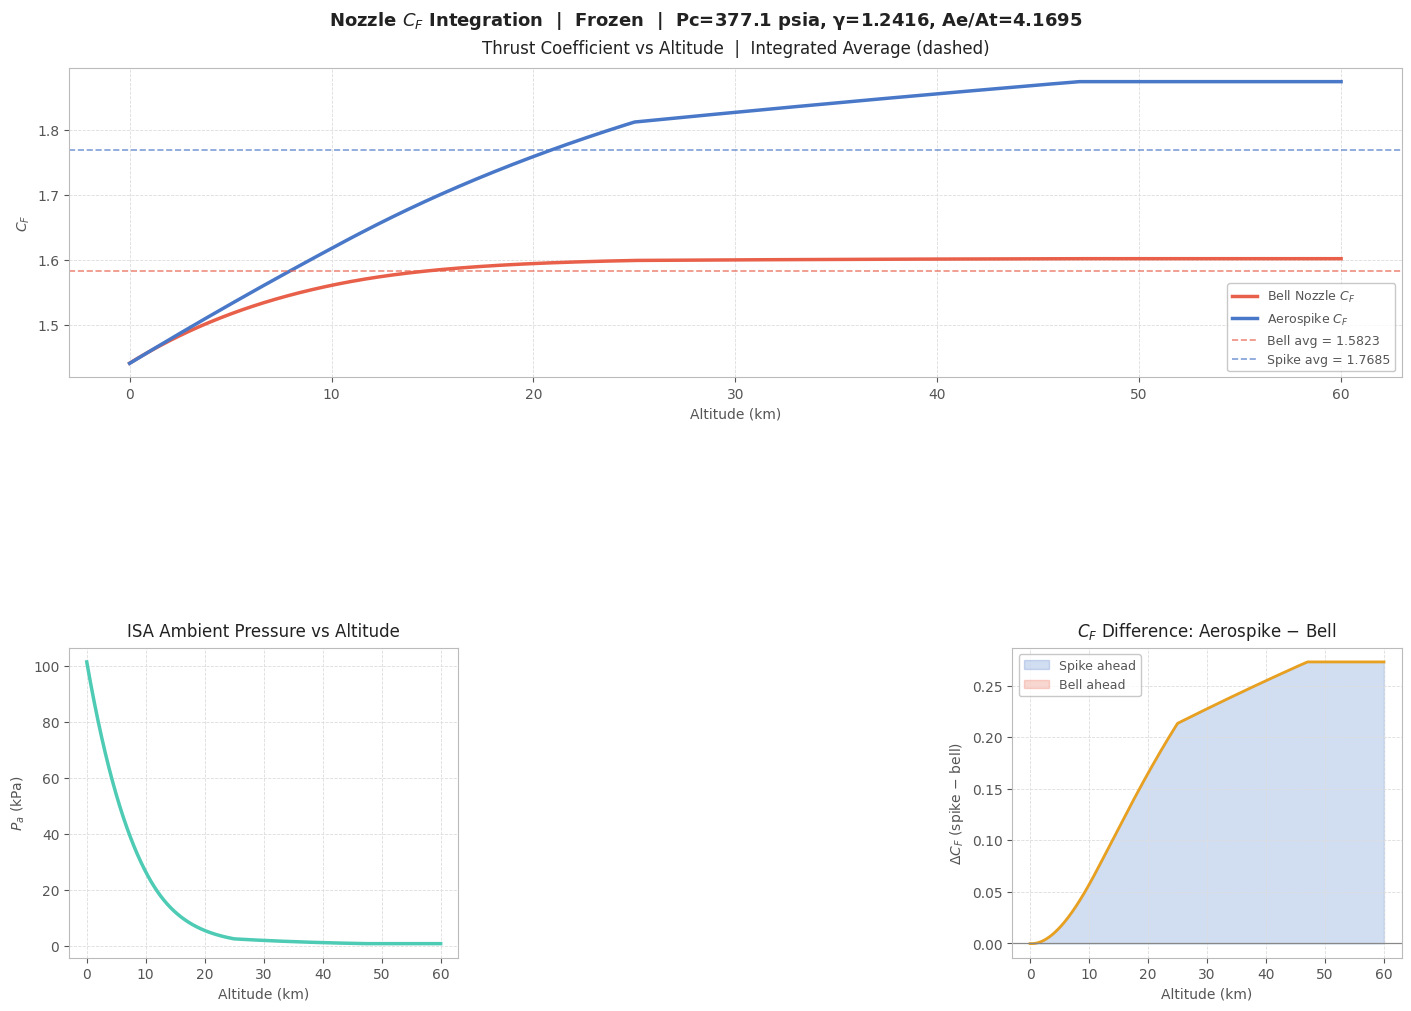

In [4]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ================================================================
FILE       = "CEA(SL)F.txt"
ASSUMPTION = "frozen"
AT_KNOWN   = 0.01338       # m²  — physical throat area, not in CEA output
H_START    =     0         # m
H_END      = 60000         # m
N_STEPS    =  5000
# ================================================================


# ------------------------------------------------------------------
# CEA Parser
# ------------------------------------------------------------------
def parse_blocks(filepath):
    with open(filepath, 'r') as f:
        content = f.read()

    results = []
    for block in re.split(r'(?=THEORETICAL ROCKET PERFORMANCE)', content):
        if 'THEORETICAL ROCKET PERFORMANCE' not in block:
            continue

        assumption = ('Equilibrium' if 'EQUILIBRIUM' in block
                      else 'Frozen' if 'FROZEN' in block else 'Unknown')

        def get_row(label):
            m = re.search(rf'{re.escape(label)}\s+([\d.E+\-]+(?:\s+[\d.E+\-]+)*)', block)
            if not m:
                return None
            raw = re.sub(r'(\d)([\+\-])(\d)', r'\1E\2\3', m.group(1))
            return [float(x) for x in raw.split()]

        of_m      = re.search(r'O/F=\s*([\d.]+)', block)
        pc_psia_m = re.search(r'Pin\s*=\s*([\d.]+)\s*PSIA', block)
        perf      = re.search(r'PERFORMANCE PARAMETERS.*?(?=MASS FRACTIONS)', block, re.DOTALL)
        pb        = perf.group(0) if perf else ''
        aeat_m    = re.search(r'Ae/At\s+([\d.]+)\s+([\d.]+)', pb)
        cstar_m   = re.search(r'CSTAR,\s*M/SEC\s+([\d.]+)', pb)
        isp_m     = re.search(r'Isp,\s*M/SEC\s+([\d.]+)\s+([\d.]+)', pb)

        gamma_row = get_row('GAMMAs')
        mach_row  = get_row('MACH NUMBER')
        son_row   = get_row('SON VEL,M/SEC')
        prat_row  = get_row('P/P1')          # [chamber, throat, exit] pressure ratios
        mach_exit = mach_row[2] if mach_row and len(mach_row) > 2 else None

        results.append({
            'assumption': assumption,
            'of':         float(of_m.group(1)) if of_m else None,
            'pc_psia':    float(pc_psia_m.group(1)) if pc_psia_m else None,
            'cstar':      float(cstar_m.group(1)) if cstar_m else None,
            'ae_at':      float(aeat_m.group(2)) if aeat_m else None,
            'isp_exit':   float(isp_m.group(2)) if isp_m else None,
            'gamma_exit': gamma_row[2] if gamma_row and len(gamma_row) > 2 else None,
            'mach_exit':  mach_exit,
            'vel_exit':   son_row[2] * mach_exit if son_row and mach_exit and len(son_row) > 2 else None,
            'pe_over_pc': prat_row[2] if prat_row and len(prat_row) > 2 else None,
        })

    return results


def select_block(results, assumption):
    target = assumption.strip().capitalize()
    for r in results:
        if r['assumption'].capitalize() == target:
            return r
    return None


# ------------------------------------------------------------------
# ISA Atmosphere (troposphere - stratosphere) 
# ------------------------------------------------------------------
def isa_pressure(h):
    h  = np.clip(np.asarray(h, dtype=float), 0, 47000)
    return np.where(
        h <= 11000,
        101325.0 * np.clip(1.0 - h / 44_307.7, 0, None) ** 5.2561,
        np.where(
            h <= 25000,
            22632.0 * np.exp(-(h - 11000) / 6_341.6),
            2488.0  * np.clip(1.0 - (h - 25_000) / 228812.0, 0, None) ** 11.388
        )
    )


# ------------------------------------------------------------------
# Thrust Coefficient Functions
# ------------------------------------------------------------------
def momentum_term_base(gamma):
    return np.sqrt(
        (2.0 * gamma**2) / (gamma - 1.0) *
        (2.0 / (gamma + 1.0)) ** ((gamma + 1.0) / (gamma - 1.0))
    )


def cf_bell(Pa, gamma, Pc, Pe, Ae_At):
    base     = momentum_term_base(gamma)
    mom_term = base * np.sqrt(1.0 - (Pe / Pc) ** ((gamma - 1.0) / gamma))
    prs_term = (Ae_At / Pc) * (Pe - Pa)
    return mom_term + prs_term


def cf_aerospike(Pa, gamma, Pc):
    base = momentum_term_base(gamma)
    return base * np.sqrt(np.clip(1.0 - (Pa / Pc) ** ((gamma - 1.0) / gamma), 0, None))


# ------------------------------------------------------------------
# Numerical Integration
# ------------------------------------------------------------------
def integrate_cf(cf_array, h_array):
    return np.trapezoid(cf_array, h_array) / (h_array[-1] - h_array[0])


# ------------------------------------------------------------------
# Main
# ------------------------------------------------------------------
def main():
    print("=" * 65)
    print("  NOZZLE THRUST COEFFICIENT (C_F) INTEGRATION ANALYSIS")
    print("=" * 65)

    results = parse_blocks(FILE)
    if not results:
        print(f"ERROR: No blocks found in {FILE}.")
        return

    cea = select_block(results, ASSUMPTION)
    if cea is None:
        print(f"ERROR: '{ASSUMPTION}' block not found. Found: {[r['assumption'] for r in results]}")
        return

    # --- Pull all values from CEA ---
    gamma  = cea['gamma_exit']
    pc_pa  = cea['pc_psia'] * 6894.76
    ae_at  = cea['ae_at']

    # Pe from CEA pressure ratio P/P1 (exit / chamber)
    # CEA reports P/P1 where P1 = Pc, so Pe = Pc * (P/P1)_exit
    if cea['pe_over_pc'] is not None:
        pe_bell = pc_pa * cea['pe_over_pc']
    else:
        # fallback: isentropic Pe from exit Mach
        me = cea['mach_exit']
        pe_bell = pc_pa * (1.0 + 0.5*(gamma - 1.0)*me**2) ** (-gamma / (gamma - 1.0))

    mdot = (AT_KNOWN * pc_pa) / cea['cstar']

    print(f"\n  CEA values used ({ASSUMPTION}):")
    print(f"    gamma (γ)          = {gamma:.4f}")
    print(f"    Pc                 = {pc_pa/1e6:.4f} MPa  ({cea['pc_psia']} PSIA)")
    print(f"    Pe_bell (fixed)    = {pe_bell:.2f} Pa")
    print(f"    Ae/At              = {ae_at:.4f}")
    print(f"    O/F                = {cea['of']}")
    print(f"    C*                 = {cea['cstar']:.2f} m/s")
    print(f"    Isp                = {cea['isp_exit']:.2f} m/s")
    print(f"    At                 = {AT_KNOWN} m²")
    print(f"    MDOT               = {mdot:.4f} kg/s")
    print(f"    Altitude range     = {H_START/1000:.0f} – {H_END/1000:.0f} km")
    print(f"    Integration steps  = {N_STEPS}")

    # --- Altitude and pressure arrays ---
    h  = np.linspace(H_START, H_END, N_STEPS)
    Pa = isa_pressure(h)

    # --- C_F arrays ---
    CF_bell  = cf_bell(Pa, gamma, pc_pa, pe_bell, ae_at)
    CF_spike = cf_aerospike(Pa, gamma, pc_pa)

    # --- Integrated averages ---
    CF_bell_avg  = integrate_cf(CF_bell,  h)
    CF_spike_avg = integrate_cf(CF_spike, h)
    advantage_pct = (CF_spike_avg / CF_bell_avg - 1.0) * 100.0

    THRUST_BELL  = CF_bell_avg  * pc_pa * AT_KNOWN
    THRUST_SPIKE = CF_spike_avg * pc_pa * AT_KNOWN

    # --- Sample table ---
    print(f"\n  {'Altitude (km)':<16} {'Pa (kPa)':<14} {'CF_bell':<14} {'CF_spike':<14}")
    print(f"  {'-'*58}")
    for idx in np.linspace(0, N_STEPS - 1, 10, dtype=int):
        print(f"  {h[idx]/1000:<16.1f} {Pa[idx]/1000:<14.3f} "
              f"{CF_bell[idx]:<14.5f} {CF_spike[idx]:<14.5f}")

    print(f"\n  Integrated Results (trapezoid rule, {H_START/1000:.0f}–{H_END/1000:.0f} km):")
    print(f"    Bell  C̄_F  = {CF_bell_avg:.5f}")
    print(f"    Spike C̄_F  = {CF_spike_avg:.5f}")
    print(f"    Aerospike advantage = {advantage_pct:+.2f}%")
    print(f"    Spike Thrust (avg)  = {THRUST_SPIKE/1000:.5f} kN")
    print(f"    Bell  Thrust (avg)  = {THRUST_BELL/1000:.5f} kN")

    # --- Term breakdown at key altitudes ---
    base = momentum_term_base(gamma)
    mom  = base * np.sqrt(1.0 - (pe_bell / pc_pa) ** ((gamma - 1.0) / gamma))

    print(f"\n  Term Breakdown:")
    print(f"  {'Altitude (km)':<12} {'Pa (kPa)':<12} {'Bell mom':<12} {'Bell prs':<12} "
          f"{'Bell CF':<12} {'Spike CF':<12}")
    print(f"  {'-'*72}")
    for h_km in [0, 10, 20, 30, 40, 50, 60]:
        h_m = h_km * 1000
        if h_m > H_END:
            continue
        pa  = float(isa_pressure(np.array([h_m]))[0])
        prs = (ae_at / pc_pa) * (pe_bell - pa)
        spk = float(cf_aerospike(np.array([pa]), gamma, pc_pa)[0])
        print(f"  {h_km:<12} {pa/1000:<12.3f} {mom:<12.5f} {prs:<12.5f} "
              f"{mom+prs:<12.5f} {spk:<12.5f}")

    # ----------------------------------------------------------------
    # Plotting
    # ----------------------------------------------------------------
    LAB_ORANGE = "#E8A020"
    LAB_RED    = "#E8604A"
    LAB_BLUE   = "#4A78C8"
    LAB_TEAL   = "#4ECBB4"
    LAB_ORANGE = "#E8A020"
    LAB_GREY   = "#888888"
    PANEL      = "#FFFFFF"
    GRID_C     = "#DDDDDD"
    SPINE_C    = "#BBBBBB"
    TEXT_C     = "#222222"
    SUBTEXT_C  = "#555555"

    fig = plt.figure(figsize=(14, 10), layout="constrained")
    fig.patch.set_facecolor(PANEL)
    gs   = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
    h_km = h / 1000

    ax1 = fig.add_subplot(gs[0, :], facecolor=PANEL)
    ax1.plot(h_km, CF_bell,  color=LAB_RED,  lw=2.5, label="Bell Nozzle $C_F$")
    ax1.plot(h_km, CF_spike, color=LAB_BLUE, lw=2.5, label="Aerospike $C_F$")
    ax1.axhline(CF_bell_avg,  color=LAB_RED,  lw=1.2, ls="--", alpha=0.7, label=f"Bell avg = {CF_bell_avg:.4f}")
    ax1.axhline(CF_spike_avg, color=LAB_BLUE, lw=1.2, ls="--", alpha=0.7, label=f"Spike avg = {CF_spike_avg:.4f}")
    ax1.set_xlabel("Altitude (km)", color=SUBTEXT_C)
    ax1.set_ylabel("$C_F$",         color=SUBTEXT_C)
    ax1.set_title("Thrust Coefficient vs Altitude  |  Integrated Average (dashed)", color=TEXT_C, pad=10)
    ax1.tick_params(colors=SUBTEXT_C)
    ax1.spines[:].set_color(SPINE_C)
    ax1.legend(facecolor=PANEL, edgecolor=SPINE_C, labelcolor=SUBTEXT_C, fontsize=9)
    ax1.grid(color=GRID_C, linestyle="--", linewidth=0.6)

    ax2 = fig.add_subplot(gs[1, 0], facecolor=PANEL)
    ax2.plot(h_km, Pa / 1000, color=LAB_TEAL, lw=2.5)
    ax2.set_xlabel("Altitude (km)", color=SUBTEXT_C)
    ax2.set_ylabel("$P_a$ (kPa)",   color=SUBTEXT_C)
    ax2.set_title("ISA Ambient Pressure vs Altitude", color=TEXT_C, pad=8)
    ax2.tick_params(colors=SUBTEXT_C)
    ax2.spines[:].set_color(SPINE_C)
    ax2.grid(color=GRID_C, linestyle="--", linewidth=0.6)

    ax3 = fig.add_subplot(gs[1, 1], facecolor=PANEL)
    delta = CF_spike - CF_bell
    ax3.fill_between(h_km, delta, 0, where=(delta > 0), color=LAB_BLUE,   alpha=0.25, label="Spike ahead")
    ax3.fill_between(h_km, delta, 0, where=(delta < 0), color=LAB_RED,    alpha=0.25, label="Bell ahead")
    ax3.plot(h_km, delta, color=LAB_ORANGE, lw=2)
    ax3.axhline(0, color=LAB_GREY, lw=0.9)
    ax3.set_xlabel("Altitude (km)",                color=SUBTEXT_C)
    ax3.set_ylabel("$\\Delta C_F$ (spike − bell)", color=SUBTEXT_C)
    ax3.set_title("$C_F$ Difference: Aerospike − Bell", color=TEXT_C, pad=8)
    ax3.tick_params(colors=SUBTEXT_C)
    ax3.spines[:].set_color(SPINE_C)
    ax3.legend(facecolor=PANEL, edgecolor=SPINE_C, labelcolor=SUBTEXT_C, fontsize=9)
    ax3.grid(color=GRID_C, linestyle="--", linewidth=0.6)

    fig.suptitle(
        f"Nozzle $C_F$ Integration  |  {ASSUMPTION.capitalize()}  |  "
        f"Pc={cea['pc_psia']} psia, γ={gamma:.4f}, Ae/At={ae_at:.4f}",
        color=TEXT_C, fontsize=13, fontweight="bold"
    )
    plt.show()


if __name__ == "__main__":
    main()

Cf comparison where pe = 1.17 kPa optimal bell nozzle at 30km altitude 

In [5]:
"""
NASA CEA Parameter Extractor
-----------------------------
Extracts: gamma (GAMMAs at exit), C*, At, Exit Velocity, Exit Mach
from a CEA output file with CHAMBER / THROAT / EXIT columns.\
HOW TO USE:
  1. Place this script in the same folder as your CEA output file.
  2. Edit FILE below.
  3. Run:  python cea_extractor.py
"""

import re

# ================================================================
#  USER SETTINGS
# ================================================================
FILE = "CEA(30km)F.txt"   # your CEA output filename
# ================================================================


def parse_blocks(filepath):
    with open(filepath, 'r') as f:
        content = f.read()

    blocks = re.split(r'(?=THEORETICAL ROCKET PERFORMANCE)', content)
    results = []

    for block in blocks:
        if 'THEORETICAL ROCKET PERFORMANCE' not in block:
            continue

        assumption = ('Equilibrium' if 'EQUILIBRIUM' in block
                      else 'Frozen' if 'FROZEN' in block else 'Unknown')

        def get_row(label):
            """Return list of floats for a data row, handling sci notation like 7.2388-2."""
            pattern = rf'{re.escape(label)}\s+([\d.E+\-]+(?:\s+[\d.E+\-]+)*)'
            m = re.search(pattern, block)
            if not m:
                return None
            raw = re.sub(r'(\d)([\+\-])(\d)', r'\1E\2\3', m.group(1))
            return [float(x) for x in raw.split()]

        # O/F
        of_m = re.search(r'O/F=\s*([\d.]+)', block)
        of   = float(of_m.group(1)) if of_m else None

        # Pc in PSIA
        pc_psia_m = re.search(r'Pin\s*=\s*([\d.]+)\s*PSIA', block)
        pc_psia   = float(pc_psia_m.group(1)) if pc_psia_m else None

        # Performance parameters block
        perf_block = re.search(r'PERFORMANCE PARAMETERS.*?(?=MASS FRACTIONS)', block, re.DOTALL)
        pb = perf_block.group(0) if perf_block else ''

        # C*
        cstar_m = re.search(r'CSTAR,\s*M/SEC\s+([\d.]+)', pb)
        cstar   = float(cstar_m.group(1)) if cstar_m else None

        # Isp at exit (second value)
        isp_m    = re.search(r'Isp,\s*M/SEC\s+([\d.]+)\s+([\d.]+)', pb)
        isp_exit = float(isp_m.group(2)) if isp_m else None

        # Column rows: [CHAMBER, THROAT, EXIT]
        gamma_row = get_row('GAMMAs')
        mach_row  = get_row('MACH NUMBER')
        son_row   = get_row('SON VEL,M/SEC')

        gamma_exit = gamma_row[2] if gamma_row and len(gamma_row) > 2 else None
        mach_exit  = mach_row[2]  if mach_row  and len(mach_row)  > 2 else None
        vel_exit   = (son_row[2] * mach_exit
                      if son_row and mach_exit and len(son_row) > 2 else None)

        results.append({
            'assumption': assumption,
            'pc_psia':    pc_psia,
            'of':         of,
            'cstar':      cstar,
            'gamma_exit': gamma_exit,
            'mach_exit':  mach_exit,
            'vel_exit':   vel_exit,
            'isp_exit':   isp_exit,
        })

    return results


def main():
    print(f"\nFile: {FILE}\n")
    results = parse_blocks(FILE)

    if not results:
        print("ERROR: No blocks found. Check your filename.")
        return

    for r in results:
        print("=" * 55)
        print(f"  {r['assumption'].upper()}  |  Pc = {r['pc_psia']} PSIA  |  O/F = {r['of']}")
        print("=" * 55)
        print(f"  C*             = {r['cstar']:.2f}  m/s")
        print(f"  Gamma (exit)   = {r['gamma_exit']:.4f}")
        print(f"  Mach (exit)    = {r['mach_exit']:.3f}")
        print(f"  Velocity (exit)= {r['vel_exit']:.2f}  m/s")
        print(f"  Isp (exit)     = {r['isp_exit']:.2f}  m/s")
        print()


if __name__ == '__main__':
    main()


File: CEA(30km)F.txt

  FROZEN  |  Pc = 377.1 PSIA  |  O/F = 5.0
  C*             = 2318.60  m/s
  Gamma (exit)   = 1.3202
  Mach (exit)    = 5.055
  Velocity (exit)= 4242.16  m/s
  Isp (exit)     = 4242.00  m/s




Reading: CEA(30km)F.txt  [frozen]

  CEA values used:
    Pc        = 377.1 PSIA  (2600014 Pa)
    O/F       = 5.0
    C*        = 2318.60 m/s
    Isp       = 4242.00 m/s
    Gamma     = 1.3202  (exit)
    Mach exit = 5.055
    Ae/At     = 71.5430  (from CEA)

  Geometry (At = 0.01338 m²):
    MDOT = 15.0040 kg/s
    At   = 133.8000 cm²   rt = 6.5261 cm  (2.5693 in)
    Ae   = 9572.4534 cm²   re = 55.1997 cm

  Running MOC (15 lines)...

  Parabolic spike fit  y(x) = a·(x − b)² + c
  Normalised (/rt):
    y(x) = 0.0010·(x − 199.5836)² + -1.2133
  Dimensioned (cm):
    y(x) = 0.0002·(x − 1302.5006)² + -7.9180


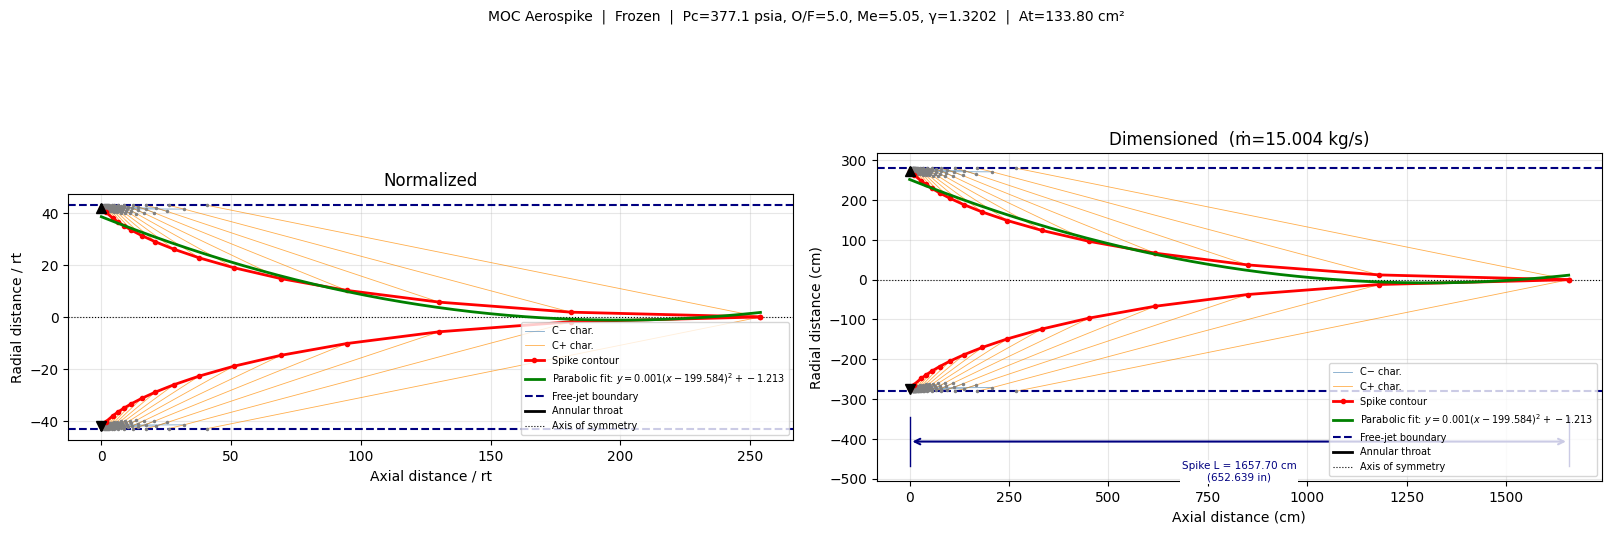

In [6]:
"""
MOC Aerospike Nozzle Contour — driven by NASA CEA output
---------------------------------------------------------
Reads gamma, Mach exit, C*, Pc, and Ae/At directly from your CEA file
via parse_blocks(), then computes and plots the aerospike spike contour via
Method of Characteristics, including C+ and C- characteristic lines.
Parabolic wall fit: y(x) = a*(x - b)^2 + c  via scipy curve_fit.

This is the Aerospike MOC for finding the contour of the nozzle.
The same equations apply just inverted so that the nozzle "wall"
runs towards itself and not away from itself.
The tip of the aerospike ends at the centerline of the conventional nozzle.
The base of the nozzle starts at the radial distance where the conventional
one would normally end. What is known as the free-jet boundary replaces
the outer wall.

The aerospike is the "flipped" version of the conventional nozzle:
  - The throat is at the OUTER radius (annular throat at top)
  - The spike wall is at the BOTTOM (centerline of the conventional nozzle)
  - Flow expands radially INWARD/downward along the spike surface
  - The free-jet boundary replaces the outer nozzle wall
"""

import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar, curve_fit

# ================================================================
#  USER SETTINGS
# ================================================================
FILE       = "CEA(30km)F.txt"   # your CEA output filename
ASSUMPTION = "frozen"          # "equilibrium" or "frozen"
AT_KNOWN   = 0.01338           # m²  — physical throat area (e.g. 20.75 in² = 0.01338 m²)
                               #        not in CEA output, must be provided here
NUM_LINES  = 15                # MOC resolution (more = smoother, try 10–50)
# ================================================================


# ------------------------------------------------------------------
# 1. Parse CEA file  (from cea_extractor.py)
# ------------------------------------------------------------------
def parse_blocks(filepath):
    with open(filepath, 'r') as f:
        content = f.read()

    blocks = re.split(r'(?=THEORETICAL ROCKET PERFORMANCE)', content)
    results = []

    for block in blocks:
        if 'THEORETICAL ROCKET PERFORMANCE' not in block:
            continue

        assumption = ('Equilibrium' if 'EQUILIBRIUM' in block
                      else 'Frozen' if 'FROZEN' in block else 'Unknown')

        def get_row(label):
            """Return list of floats for a data row, handling sci notation like 7.2388-2."""
            pattern = rf'{re.escape(label)}\s+([\d.E+\-]+(?:\s+[\d.E+\-]+)*)'
            m = re.search(pattern, block)
            if not m:
                return None
            raw = re.sub(r'(\d)([\+\-])(\d)', r'\1E\2\3', m.group(1))
            return [float(x) for x in raw.split()]

        # O/F
        of_m = re.search(r'O/F=\s*([\d.]+)', block)
        of   = float(of_m.group(1)) if of_m else None

        # Pc in PSIA
        pc_psia_m = re.search(r'Pin\s*=\s*([\d.]+)\s*PSIA', block)
        pc_psia   = float(pc_psia_m.group(1)) if pc_psia_m else None

        # Performance parameters block
        perf_block = re.search(r'PERFORMANCE PARAMETERS.*?(?=MASS FRACTIONS)', block, re.DOTALL)
        pb = perf_block.group(0) if perf_block else ''

        # Ae/At (throat=1.0, exit=second value)
        aeat_m = re.search(r'Ae/At\s+([\d.]+)\s+([\d.]+)', pb)
        ae_at  = float(aeat_m.group(2)) if aeat_m else None

        # C*
        cstar_m = re.search(r'CSTAR,\s*M/SEC\s+([\d.]+)', pb)
        cstar   = float(cstar_m.group(1)) if cstar_m else None

        # Isp at exit (second value)
        isp_m    = re.search(r'Isp,\s*M/SEC\s+([\d.]+)\s+([\d.]+)', pb)
        isp_exit = float(isp_m.group(2)) if isp_m else None

        # Column rows: [CHAMBER, THROAT, EXIT]
        gamma_row = get_row('GAMMAs')
        mach_row  = get_row('MACH NUMBER')
        son_row   = get_row('SON VEL,M/SEC')

        gamma_exit = gamma_row[2] if gamma_row and len(gamma_row) > 2 else None
        mach_exit  = mach_row[2]  if mach_row  and len(mach_row)  > 2 else None
        vel_exit   = (son_row[2] * mach_exit
                      if son_row and mach_exit and len(son_row) > 2 else None)

        results.append({
            'assumption': assumption,
            'pc_psia':    pc_psia,
            'of':         of,
            'cstar':      cstar,
            'gamma_exit': gamma_exit,
            'mach_exit':  mach_exit,
            'vel_exit':   vel_exit,
            'ae_at':      ae_at,
            'isp_exit':   isp_exit,
        })

    return results


def select_block(results, assumption):
    """Return the result block matching the requested assumption."""
    target = assumption.strip().capitalize()
    for r in results:
        if r['assumption'].capitalize() == target:
            return r
    return None


# ------------------------------------------------------------------
# 2. Prandtl-Meyer functions
# ------------------------------------------------------------------
def prandtl_meyer(mach, gamma):
    return (
        np.sqrt((gamma + 1.) / (gamma - 1.)) *
        np.arctan(np.sqrt((gamma - 1.) * (mach**2 - 1.) / (gamma + 1.))) -
        np.arctan(np.sqrt(mach**2 - 1.))
    )

def solve_pm(mach, nu, gamma):
    return nu - prandtl_meyer(mach, gamma)


# ------------------------------------------------------------------
# 3. Parabola model  y(x) = a*(x - b)^2 + c
# ------------------------------------------------------------------
def parabola(x, a, b, c):
    return a * np.power(x - b, 2) + c


# ------------------------------------------------------------------
# 4. MOC kernel — same math as conventional, connectivity identical
# ------------------------------------------------------------------
def compute_moc(gamma, mach_exit, num_lines):
    angle_max = 0.5 * prandtl_meyer(mach_exit, gamma)

    idk_count = num_lines
    for idx in range(1, num_lines):
        for idy in range(idx, num_lines):
            idk_count += 1
        idk_count += 1
    num_points = idk_count + 1

    nus    = np.zeros(num_points)
    thetas = np.zeros(num_points)
    machs  = np.zeros(num_points)
    mus    = np.zeros(num_points)
    y      = np.zeros(num_points)
    x      = np.zeros(num_points)

    constant_minus = np.zeros(num_lines)
    constant_plus  = np.zeros(num_lines)

    c_minus_lines = []
    c_plus_lines  = []

    # ---- Initial expansion fan ----
    delta_theta0 = angle_max / num_lines
    nus[0]    = delta_theta0
    thetas[0] = delta_theta0
    sol = root_scalar(solve_pm, x0=1.1, bracket=[1.000001, 20], args=(nus[0], gamma))
    machs[0]  = sol.root
    mus[0]    = np.arcsin(1. / machs[0])
    constant_minus[0] = thetas[0] + nus[0]
    constant_plus[0]  = thetas[0] - nus[0]
    x[0] = -1. / np.tan(0.5*thetas[0] - 0.5*(np.pi/2. + mus[0]))
    y[0] = 0.

    delta_theta = (angle_max - delta_theta0) / (num_lines - 1)
    for idx in range(1, num_lines):
        thetas[idx] = thetas[idx-1] + delta_theta
        nus[idx]    = thetas[idx]
        sol = root_scalar(solve_pm, x0=1.1, bracket=[1.00001, 20], args=(nus[idx], gamma))
        machs[idx]  = sol.root
        mus[idx]    = np.arcsin(1. / machs[idx])
        constant_minus[idx] = thetas[idx] + nus[idx]

        dydx_p = np.tan(0.5*(thetas[idx-1]+thetas[idx]) + 0.5*(mus[idx-1]+mus[idx]))
        dydx_m = np.tan(thetas[idx] - mus[idx])
        y[idx]  = (dydx_p*(-1./dydx_m - x[idx-1]) + y[idx-1]) / (1 - dydx_p/dydx_m)
        x[idx]  = (y[idx] - 1.) / dydx_m

    # ---- Upper surface point ----
    idx = num_lines
    thetas[idx] = thetas[idx-1]
    nus[idx]    = nus[idx-1]
    machs[idx]  = machs[idx-1]
    mus[idx]    = mus[idx-1]
    dydx_m = np.tan(0.5*(angle_max + thetas[idx]))
    dydx_p = np.tan(0.5*(thetas[idx-1]+thetas[idx]) + 0.5*(mus[idx-1]+mus[idx]))
    y[idx]  = (dydx_p*(-x[idx-1] - 1./dydx_m) + y[idx-1]) / (1. - dydx_p/dydx_m)
    x[idx]  = (y[idx] - 1) / dydx_m

    # ---- Remaining characteristic lines ----
    idk = num_lines
    for idx in range(1, num_lines):
        c_minus = [idx]
        c_plus  = []

        for idy in range(idx, num_lines):
            idk += 1
            if idy == idx:
                thetas[idk] = 0
                nus[idk]    = constant_minus[idx]
                constant_plus[idx] = thetas[idk] - nus[idk]
                c_plus.append(idk)
            else:
                thetas[idk] = 0.5*(constant_minus[idy] + constant_plus[idx])
                nus[idk]    = 0.5*(constant_minus[idy] - constant_plus[idx])
                c_minus.append(idk)
                c_plus.append(idk)

            sol = root_scalar(solve_pm, x0=1.1, bracket=[1.0001, 20], args=(nus[idk], gamma))
            machs[idk] = sol.root
            mus[idk]   = np.arcsin(1. / machs[idk])

            idk_prev = idk - (num_lines - idx + 1)
            if idy == idx:
                y[idk] = 0.
                x[idk] = x[idk_prev] - y[idk_prev] / np.tan(thetas[idk_prev] - mus[idk_prev])
            else:
                dydx_p = np.tan(0.5*(thetas[idk-1]+thetas[idk]) + 0.5*(mus[idk-1]+mus[idk]))
                dydx_m = np.tan(0.5*(thetas[idk]+thetas[idk_prev]) - 0.5*(mus[idk]+mus[idk_prev]))
                y[idk] = (dydx_p*(-y[idk_prev]/dydx_m + x[idk_prev] - x[idk-1]) + y[idk-1]) / (1. - dydx_p/dydx_m)
                x[idk] = x[idk_prev] + (y[idk] - y[idk_prev]) / dydx_m

        # Wall point
        idk += 1
        thetas[idk] = thetas[idk-1]
        nus[idk]    = nus[idk-1]
        machs[idk]  = machs[idk-1]
        mus[idk]    = mus[idk-1]

        idk_prev = idk - (num_lines - idx + 1)
        dydx_m = np.tan(0.5*(thetas[idk_prev] + thetas[idk]))
        dydx_p = np.tan(0.5*(thetas[idk-1]+thetas[idk]) + 0.5*(mus[idk-1]+mus[idk]))
        y[idk] = (dydx_p*(-y[idk_prev]/dydx_m + x[idk_prev] - x[idk-1]) + y[idk-1]) / (1. - dydx_p/dydx_m)
        x[idk] = x[idk_prev] + (y[idk] - y[idk_prev]) / dydx_m

        c_plus.append(idk)
        c_minus_lines.append(c_minus)
        c_plus_lines.append(c_plus)

    return x, y, machs, c_minus_lines, c_plus_lines


# ------------------------------------------------------------------
# 5. Extract wall (spike) contour
# ------------------------------------------------------------------
def extract_wall(x, y, num_lines):
    wall_x = [0.0]
    wall_y = [1.0]
    idk = num_lines
    wall_x.append(x[idk])
    wall_y.append(y[idk])
    for idx in range(1, num_lines):
        for idy in range(idx, num_lines):
            idk += 1
        idk += 1
        wall_x.append(x[idk])
        wall_y.append(y[idk])
    return np.array(wall_x), np.array(wall_y)


# ------------------------------------------------------------------
# 6. Flip coordinates for aerospike:
#    Conventional:  throat at y=1 (top wall), centerline at y=0
#    Aerospike:     throat at r=rt (outer annulus), spike tip at r=0
#
#    Flip:  y_spike = y_max - y_conv  (invert radial axis)
#           x_spike = x_conv          (axial stays the same)
#
#    This maps:
#      conventional wall  (y = high)  → spike tip  (r = low)
#      conventional centerline (y=0)  → free-jet boundary (r = high)
# ------------------------------------------------------------------
def flip_to_aerospike(x, y, y_max):
    return x.copy(), y_max - y


# ------------------------------------------------------------------
# 7. Main
# ------------------------------------------------------------------
def main():
    print(f"\nReading: {FILE}  [{ASSUMPTION}]\n")
    results = parse_blocks(FILE)

    if not results:
        print(f"ERROR: No blocks found in {FILE}. Check your filename.")
        return

    cea = select_block(results, ASSUMPTION)
    if cea is None:
        found = [r['assumption'] for r in results]
        print(f"ERROR: Could not find '{ASSUMPTION}' block. Found: {found}")
        return

    # --- Pull all values from CEA output ---
    gamma     = cea['gamma_exit']
    mach_exit = cea['mach_exit']
    cstar     = cea['cstar']
    pc_psia   = cea['pc_psia']
    ae_at_cea = cea['ae_at']

    # --- Derive remaining quantities from CEA values + AT_KNOWN ---
    pc_pa = pc_psia * 6894.76                   # Pa
    mdot  = (AT_KNOWN * pc_pa) / cstar          # kg/s  from At·Pc/C*
    rt    = np.sqrt(AT_KNOWN / np.pi)           # m
    ae_m2 = AT_KNOWN * ae_at_cea                # m²

    print(f"  CEA values used:")
    print(f"    Pc        = {pc_psia} PSIA  ({pc_pa:.0f} Pa)")
    print(f"    O/F       = {cea['of']}")
    print(f"    C*        = {cstar:.2f} m/s")
    print(f"    Isp       = {cea['isp_exit']:.2f} m/s")
    print(f"    Gamma     = {gamma:.4f}  (exit)")
    print(f"    Mach exit = {mach_exit:.3f}")
    print(f"    Ae/At     = {ae_at_cea:.4f}  (from CEA)")

    print(f"\n  Geometry (At = {AT_KNOWN} m²):")
    print(f"    MDOT = {mdot:.4f} kg/s")
    print(f"    At   = {AT_KNOWN*1e4:.4f} cm²   rt = {rt*100:.4f} cm  ({rt*100/2.54:.4f} in)")
    print(f"    Ae   = {ae_m2*1e4:.4f} cm²   re = {np.sqrt(ae_m2/np.pi)*100:.4f} cm")

    print(f"\n  Running MOC ({NUM_LINES} lines)...")
    x_norm, y_norm, machs, c_minus_lines, c_plus_lines = \
        compute_moc(gamma, mach_exit, NUM_LINES)

    y_max_norm = y_norm.max()

    # --- Normalized aerospike coords ---
    xa_norm, ya_norm   = flip_to_aerospike(x_norm, y_norm, y_max_norm)
    wall_xn, wall_yn   = extract_wall(x_norm, y_norm, NUM_LINES)
    spike_xn, spike_yn = flip_to_aerospike(wall_xn, wall_yn, y_max_norm)
    freejet_yn_norm    = y_max_norm

    # --- Scale to real dimensions (cm) ---
    scale_cm   = rt * 100
    xa_real    = xa_norm  * scale_cm
    ya_real    = ya_norm  * scale_cm
    spike_xr   = spike_xn * scale_cm
    spike_yr   = spike_yn * scale_cm
    freejet_yr = freejet_yn_norm * scale_cm

    # --- Parabolic fit on spike contour ---
    popt_n, _ = curve_fit(parabola, spike_xn, spike_yn,
                          p0=[0.1, spike_xn[-1], spike_yn[-1]])
    a_n, b_n, c_n = popt_n

    xfit_n = np.linspace(0, np.max(spike_xn), 300)
    yfit_n = parabola(xfit_n, *popt_n)

    a_r = a_n / scale_cm
    b_r = b_n * scale_cm
    c_r = c_n * scale_cm

    xfit_r = xfit_n * scale_cm
    yfit_r = yfit_n * scale_cm

    print(f"\n  Parabolic spike fit  y(x) = a·(x − b)² + c")
    print(f"  Normalised (/rt):")
    print(f"    y(x) = {a_n:.4f}·(x − {b_n:.4f})² + {c_n:.4f}")
    print(f"  Dimensioned (cm):")
    print(f"    y(x) = {a_r:.4f}·(x − {b_r:.4f})² + {c_r:.4f}")

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), layout='constrained')
    fig.suptitle(
        f'MOC Aerospike  |  {ASSUMPTION.capitalize()}  |  '
        f'Pc={pc_psia} psia, O/F={cea["of"]}, Me={mach_exit:.2f}, γ={gamma:.4f}  |  '
        f'At={AT_KNOWN*1e4:.2f} cm²',
        fontsize=10
    )

    plot_configs = [
        (axes[0], xa_norm, ya_norm, spike_xn, spike_yn, xfit_n, yfit_n,
         freejet_yn_norm, 1.0, 'Axial distance / rt', 'Normalized'),
        (axes[1], xa_real, ya_real, spike_xr, spike_yr, xfit_r, yfit_r,
         freejet_yr, scale_cm, 'Axial distance (cm)',
         f'Dimensioned  (ṁ={mdot:.3f} kg/s)'),
    ]

    for ax, xd, yd, sxd, syd, xfd, yfd, fj_y, sc, xlabel, title in plot_configs:
        is_dim = (sc != 1.0)

        # C- characteristic lines
        for i, line in enumerate(c_minus_lines):
            lx = [xd[j] for j in line]
            ly = [yd[j] for j in line]
            ax.plot(lx,  ly, '-', color='steelblue', lw=0.6, alpha=0.7,
                    label='C− char.' if i == 0 else '')
            ax.plot(lx, [-v for v in ly], '-', color='steelblue', lw=0.6, alpha=0.7)

        # C+ characteristic lines
        for i, line in enumerate(c_plus_lines):
            lx = [xd[j] for j in line]
            ly = [yd[j] for j in line]
            ax.plot(lx,  ly, '-', color='darkorange', lw=0.6, alpha=0.7,
                    label='C+ char.' if i == 0 else '')
            ax.plot(lx, [-v for v in ly], '-', color='darkorange', lw=0.6, alpha=0.7)

        # Interior field points
        ax.plot(xd,  yd, 'o', ms=1.5, color='gray', zorder=3)
        ax.plot(xd, -yd, 'o', ms=1.5, color='gray', zorder=3)

        # Spike contour
        ax.plot(sxd,  syd, 'r-o', ms=3, lw=2, zorder=5, label='Spike contour')
        ax.plot(sxd, -syd, 'r-o', ms=3, lw=2, zorder=5)

        # Parabolic fit overlay
        ax.plot(xfd,  yfd, 'g-', lw=2, zorder=6,
                label=fr'Parabolic fit: $y={a_n:.3f}(x-{b_n:.3f})^2+{c_n:.3f}$')

        # Free-jet boundary
        ax.axhline( fj_y, color='navy', lw=1.5, linestyle='--', label='Free-jet boundary')
        ax.axhline(-fj_y, color='navy', lw=1.5, linestyle='--')

        # Annular throat at x=0
        ax.plot([0, 0], [ syd[0],  fj_y], 'k-', lw=2, zorder=6, label='Annular throat')
        ax.plot([0, 0], [-syd[0], -fj_y], 'k-', lw=2, zorder=6)
        ax.plot(0,  syd[0], 'k^', ms=7, zorder=7)
        ax.plot(0, -syd[0], 'kv', ms=7, zorder=7)

        # Axis of symmetry
        ax.axhline(0, color='k', lw=0.8, linestyle=':', label='Axis of symmetry')

        # Dimension annotation on dimensioned plot
        if is_dim:
            spike_len   = spike_xr[-1]
            annot_y_bot = -fj_y * 1.45

            ax.annotate(
                '', xy=(spike_len, annot_y_bot), xytext=(0, annot_y_bot),
                arrowprops=dict(arrowstyle='<->', color='navy', lw=1.5)
            )
            ax.text(
                spike_len / 2, annot_y_bot * 1.12,
                f'Spike L = {spike_len:.2f} cm\n({spike_len/2.54:.3f} in)',
                ha='center', va='top', fontsize=7.5, color='navy',
                bbox=dict(fc='white', ec='none', pad=1)
            )
            ax.plot([0,         0        ], [annot_y_bot*0.85, annot_y_bot*1.15],
                    color='navy', lw=1)
            ax.plot([spike_len, spike_len], [annot_y_bot*0.85, annot_y_bot*1.15],
                    color='navy', lw=1)

        ax.set_xlabel(xlabel)
        ax.set_ylabel('Radial distance' + (' / rt' if not is_dim else ' (cm)'))
        ax.set_title(title)
        ax.set_aspect('equal', 'box')
        ax.legend(fontsize=7, loc='lower right')
        ax.grid(True, alpha=0.3)

    plt.show()


if __name__ == '__main__':
    main()

  NOZZLE THRUST COEFFICIENT (C_F) INTEGRATION ANALYSIS

  CEA values used (frozen):
    gamma (γ)          = 1.3202
    Pc                 = 2.6000 MPa  (377.1 PSIA)
    Pe_bell (fixed)    = 3167.95 Pa
    Ae/At              = 71.5430
    O/F                = 5.0
    C*                 = 2318.60 m/s
    Isp                = 4242.00 m/s
    At                 = 0.01338 m²
    MDOT               = 15.0040 kg/s
    Altitude range     = 0 – 60 km
    Integration steps  = 5000

  Altitude (km)    Pa (kPa)       CF_bell        CF_spike      
  ----------------------------------------------------------
  0.0              101.325        -0.97395       1.42198       
  6.7              43.034         0.63000        1.52934       
  13.3             15.691         1.38238        1.62383       
  20.0             5.478          1.66341        1.69673       
  26.7             2.290          1.75113        1.74288       
  33.3             1.631          1.76928        1.75810       
  40.0       

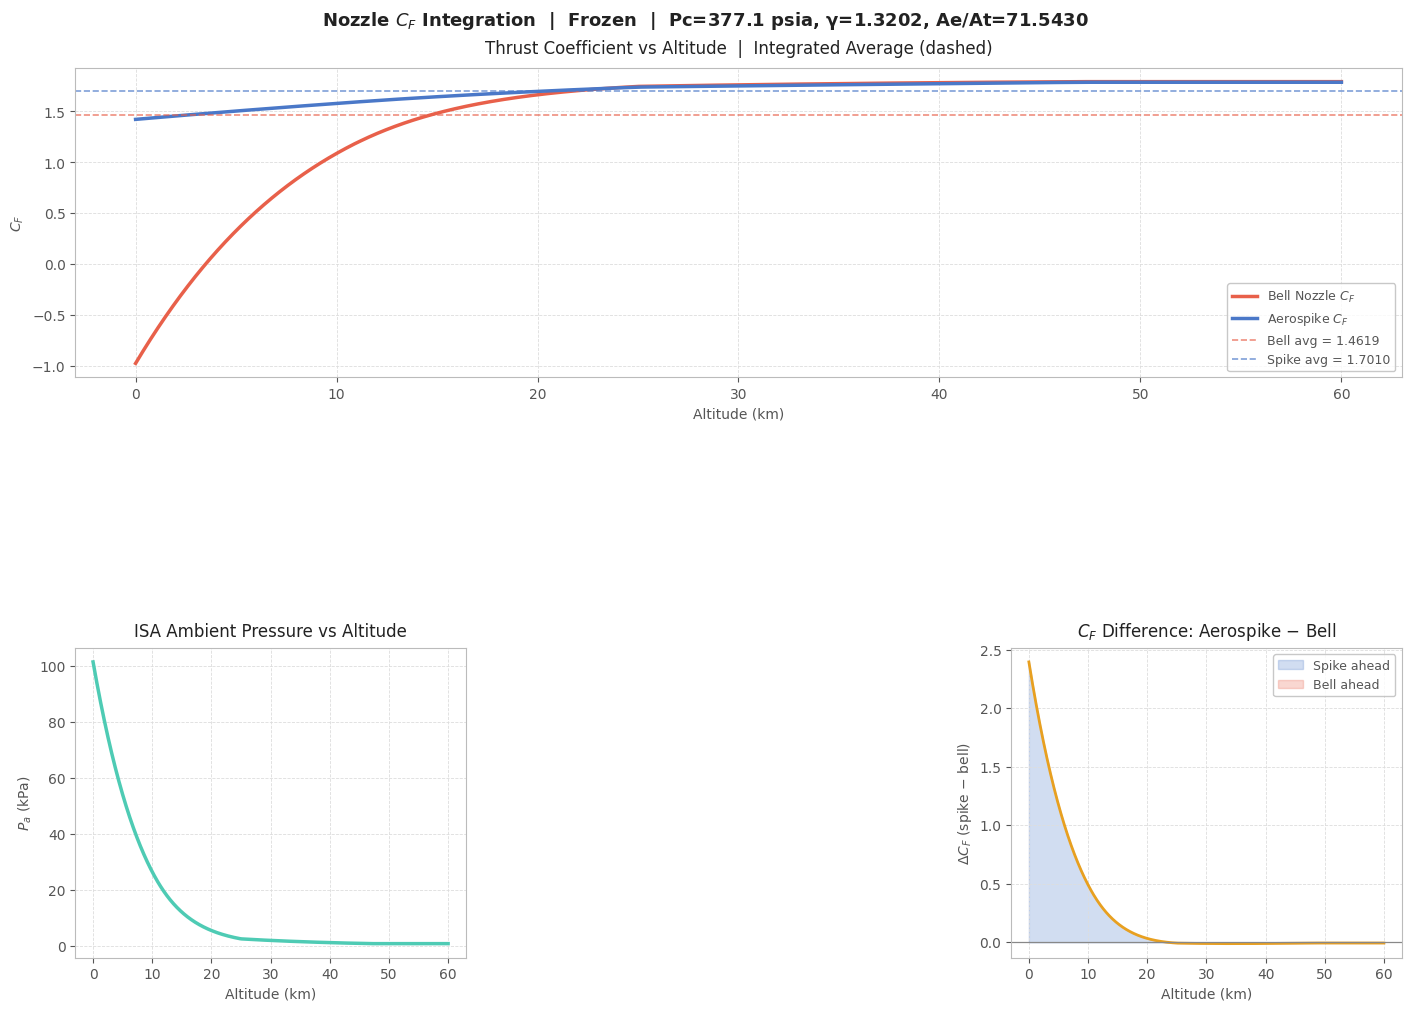

In [7]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ================================================================
FILE       = "CEA(30km)F.txt"
ASSUMPTION = "frozen"
AT_KNOWN   = 0.01338       # m²  — physical throat area, not in CEA output
H_START    =     0         # m
H_END      = 60000         # m
N_STEPS    =  5000
# ================================================================


# ------------------------------------------------------------------
# CEA Parser
# ------------------------------------------------------------------
def parse_blocks(filepath):
    with open(filepath, 'r') as f:
        content = f.read()

    results = []
    for block in re.split(r'(?=THEORETICAL ROCKET PERFORMANCE)', content):
        if 'THEORETICAL ROCKET PERFORMANCE' not in block:
            continue

        assumption = ('Equilibrium' if 'EQUILIBRIUM' in block
                      else 'Frozen' if 'FROZEN' in block else 'Unknown')

        def get_row(label):
            m = re.search(rf'{re.escape(label)}\s+([\d.E+\-]+(?:\s+[\d.E+\-]+)*)', block)
            if not m:
                return None
            raw = re.sub(r'(\d)([\+\-])(\d)', r'\1E\2\3', m.group(1))
            return [float(x) for x in raw.split()]

        of_m      = re.search(r'O/F=\s*([\d.]+)', block)
        pc_psia_m = re.search(r'Pin\s*=\s*([\d.]+)\s*PSIA', block)
        perf      = re.search(r'PERFORMANCE PARAMETERS.*?(?=MASS FRACTIONS)', block, re.DOTALL)
        pb        = perf.group(0) if perf else ''
        aeat_m    = re.search(r'Ae/At\s+([\d.]+)\s+([\d.]+)', pb)
        cstar_m   = re.search(r'CSTAR,\s*M/SEC\s+([\d.]+)', pb)
        isp_m     = re.search(r'Isp,\s*M/SEC\s+([\d.]+)\s+([\d.]+)', pb)

        gamma_row = get_row('GAMMAs')
        mach_row  = get_row('MACH NUMBER')
        son_row   = get_row('SON VEL,M/SEC')
        prat_row  = get_row('P/P1')          # [chamber, throat, exit] pressure ratios
        mach_exit = mach_row[2] if mach_row and len(mach_row) > 2 else None

        results.append({
            'assumption': assumption,
            'of':         float(of_m.group(1)) if of_m else None,
            'pc_psia':    float(pc_psia_m.group(1)) if pc_psia_m else None,
            'cstar':      float(cstar_m.group(1)) if cstar_m else None,
            'ae_at':      float(aeat_m.group(2)) if aeat_m else None,
            'isp_exit':   float(isp_m.group(2)) if isp_m else None,
            'gamma_exit': gamma_row[2] if gamma_row and len(gamma_row) > 2 else None,
            'mach_exit':  mach_exit,
            'vel_exit':   son_row[2] * mach_exit if son_row and mach_exit and len(son_row) > 2 else None,
            'pe_over_pc': prat_row[2] if prat_row and len(prat_row) > 2 else None,
        })

    return results


def select_block(results, assumption):
    target = assumption.strip().capitalize()
    for r in results:
        if r['assumption'].capitalize() == target:
            return r
    return None


# ------------------------------------------------------------------
# ISA Atmosphere (troposphere - stratosphere) 
# ------------------------------------------------------------------
def isa_pressure(h):
    h  = np.clip(np.asarray(h, dtype=float), 0, 47000)
    return np.where(
        h <= 11000,
        101325.0 * np.clip(1.0 - h / 44_307.7, 0, None) ** 5.2561,
        np.where(
            h <= 25000,
            22632.0 * np.exp(-(h - 11000) / 6_341.6),
            2488.0  * np.clip(1.0 - (h - 25_000) / 228812.0, 0, None) ** 11.388
        )
    )


# ------------------------------------------------------------------
# Thrust Coefficient Functions
# ------------------------------------------------------------------
def momentum_term_base(gamma):
    return np.sqrt(
        (2.0 * gamma**2) / (gamma - 1.0) *
        (2.0 / (gamma + 1.0)) ** ((gamma + 1.0) / (gamma - 1.0))
    )


def cf_bell(Pa, gamma, Pc, Pe, Ae_At):
    base     = momentum_term_base(gamma)
    mom_term = base * np.sqrt(1.0 - (Pe / Pc) ** ((gamma - 1.0) / gamma))
    prs_term = (Ae_At / Pc) * (Pe - Pa)
    return mom_term + prs_term


def cf_aerospike(Pa, gamma, Pc):
    base = momentum_term_base(gamma)
    return base * np.sqrt(np.clip(1.0 - (Pa / Pc) ** ((gamma - 1.0) / gamma), 0, None))


# ------------------------------------------------------------------
# Numerical Integration
# ------------------------------------------------------------------
def integrate_cf(cf_array, h_array):
    return np.trapezoid(cf_array, h_array) / (h_array[-1] - h_array[0])


# ------------------------------------------------------------------
# Main
# ------------------------------------------------------------------
def main():
    print("=" * 65)
    print("  NOZZLE THRUST COEFFICIENT (C_F) INTEGRATION ANALYSIS")
    print("=" * 65)

    results = parse_blocks(FILE)
    if not results:
        print(f"ERROR: No blocks found in {FILE}.")
        return

    cea = select_block(results, ASSUMPTION)
    if cea is None:
        print(f"ERROR: '{ASSUMPTION}' block not found. Found: {[r['assumption'] for r in results]}")
        return

    # --- Pull all values from CEA ---
    gamma  = cea['gamma_exit']
    pc_pa  = cea['pc_psia'] * 6894.76
    ae_at  = cea['ae_at']

    # Pe from CEA pressure ratio P/P1 (exit / chamber)
    # CEA reports P/P1 where P1 = Pc, so Pe = Pc * (P/P1)_exit
    if cea['pe_over_pc'] is not None:
        pe_bell = pc_pa * cea['pe_over_pc']
    else:
        # fallback: isentropic Pe from exit Mach
        me = cea['mach_exit']
        pe_bell = pc_pa * (1.0 + 0.5*(gamma - 1.0)*me**2) ** (-gamma / (gamma - 1.0))

    mdot = (AT_KNOWN * pc_pa) / cea['cstar']

    print(f"\n  CEA values used ({ASSUMPTION}):")
    print(f"    gamma (γ)          = {gamma:.4f}")
    print(f"    Pc                 = {pc_pa/1e6:.4f} MPa  ({cea['pc_psia']} PSIA)")
    print(f"    Pe_bell (fixed)    = {pe_bell:.2f} Pa")
    print(f"    Ae/At              = {ae_at:.4f}")
    print(f"    O/F                = {cea['of']}")
    print(f"    C*                 = {cea['cstar']:.2f} m/s")
    print(f"    Isp                = {cea['isp_exit']:.2f} m/s")
    print(f"    At                 = {AT_KNOWN} m²")
    print(f"    MDOT               = {mdot:.4f} kg/s")
    print(f"    Altitude range     = {H_START/1000:.0f} – {H_END/1000:.0f} km")
    print(f"    Integration steps  = {N_STEPS}")

    # --- Altitude and pressure arrays ---
    h  = np.linspace(H_START, H_END, N_STEPS)
    Pa = isa_pressure(h)

    # --- C_F arrays ---
    CF_bell  = cf_bell(Pa, gamma, pc_pa, pe_bell, ae_at)
    CF_spike = cf_aerospike(Pa, gamma, pc_pa)

    # --- Integrated averages ---
    CF_bell_avg  = integrate_cf(CF_bell,  h)
    CF_spike_avg = integrate_cf(CF_spike, h)
    advantage_pct = (CF_spike_avg / CF_bell_avg - 1.0) * 100.0

    THRUST_BELL  = CF_bell_avg  * pc_pa * AT_KNOWN
    THRUST_SPIKE = CF_spike_avg * pc_pa * AT_KNOWN

    # --- Sample table ---
    print(f"\n  {'Altitude (km)':<16} {'Pa (kPa)':<14} {'CF_bell':<14} {'CF_spike':<14}")
    print(f"  {'-'*58}")
    for idx in np.linspace(0, N_STEPS - 1, 10, dtype=int):
        print(f"  {h[idx]/1000:<16.1f} {Pa[idx]/1000:<14.3f} "
              f"{CF_bell[idx]:<14.5f} {CF_spike[idx]:<14.5f}")

    print(f"\n  Integrated Results (trapezoid rule, {H_START/1000:.0f}–{H_END/1000:.0f} km):")
    print(f"    Bell  C̄_F  = {CF_bell_avg:.5f}")
    print(f"    Spike C̄_F  = {CF_spike_avg:.5f}")
    print(f"    Aerospike advantage = {advantage_pct:+.2f}%")
    print(f"    Spike Thrust (avg)  = {THRUST_SPIKE/1000:.5f} kN")
    print(f"    Bell  Thrust (avg)  = {THRUST_BELL/1000:.5f} kN")

    # --- Term breakdown at key altitudes ---
    base = momentum_term_base(gamma)
    mom  = base * np.sqrt(1.0 - (pe_bell / pc_pa) ** ((gamma - 1.0) / gamma))

    print(f"\n  Term Breakdown:")
    print(f"  {'Altitude (km)':<12} {'Pa (kPa)':<12} {'Bell mom':<12} {'Bell prs':<12} "
          f"{'Bell CF':<12} {'Spike CF':<12}")
    print(f"  {'-'*72}")
    for h_km in [0, 10, 20, 30, 40, 50, 60]:
        h_m = h_km * 1000
        if h_m > H_END:
            continue
        pa  = float(isa_pressure(np.array([h_m]))[0])
        prs = (ae_at / pc_pa) * (pe_bell - pa)
        spk = float(cf_aerospike(np.array([pa]), gamma, pc_pa)[0])
        print(f"  {h_km:<12} {pa/1000:<12.3f} {mom:<12.5f} {prs:<12.5f} "
              f"{mom+prs:<12.5f} {spk:<12.5f}")

    # ----------------------------------------------------------------
    # Plotting
    # ----------------------------------------------------------------
    LAB_ORANGE = "#E8A020"
    LAB_RED    = "#E8604A"
    LAB_BLUE   = "#4A78C8"
    LAB_TEAL   = "#4ECBB4"
    LAB_ORANGE = "#E8A020"
    LAB_GREY   = "#888888"
    PANEL      = "#FFFFFF"
    GRID_C     = "#DDDDDD"
    SPINE_C    = "#BBBBBB"
    TEXT_C     = "#222222"
    SUBTEXT_C  = "#555555"

    fig = plt.figure(figsize=(14, 10), layout="constrained")
    fig.patch.set_facecolor(PANEL)
    gs   = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
    h_km = h / 1000

    ax1 = fig.add_subplot(gs[0, :], facecolor=PANEL)
    ax1.plot(h_km, CF_bell,  color=LAB_RED,  lw=2.5, label="Bell Nozzle $C_F$")
    ax1.plot(h_km, CF_spike, color=LAB_BLUE, lw=2.5, label="Aerospike $C_F$")
    ax1.axhline(CF_bell_avg,  color=LAB_RED,  lw=1.2, ls="--", alpha=0.7, label=f"Bell avg = {CF_bell_avg:.4f}")
    ax1.axhline(CF_spike_avg, color=LAB_BLUE, lw=1.2, ls="--", alpha=0.7, label=f"Spike avg = {CF_spike_avg:.4f}")
    ax1.set_xlabel("Altitude (km)", color=SUBTEXT_C)
    ax1.set_ylabel("$C_F$",         color=SUBTEXT_C)
    ax1.set_title("Thrust Coefficient vs Altitude  |  Integrated Average (dashed)", color=TEXT_C, pad=10)
    ax1.tick_params(colors=SUBTEXT_C)
    ax1.spines[:].set_color(SPINE_C)
    ax1.legend(facecolor=PANEL, edgecolor=SPINE_C, labelcolor=SUBTEXT_C, fontsize=9)
    ax1.grid(color=GRID_C, linestyle="--", linewidth=0.6)

    ax2 = fig.add_subplot(gs[1, 0], facecolor=PANEL)
    ax2.plot(h_km, Pa / 1000, color=LAB_TEAL, lw=2.5)
    ax2.set_xlabel("Altitude (km)", color=SUBTEXT_C)
    ax2.set_ylabel("$P_a$ (kPa)",   color=SUBTEXT_C)
    ax2.set_title("ISA Ambient Pressure vs Altitude", color=TEXT_C, pad=8)
    ax2.tick_params(colors=SUBTEXT_C)
    ax2.spines[:].set_color(SPINE_C)
    ax2.grid(color=GRID_C, linestyle="--", linewidth=0.6)

    ax3 = fig.add_subplot(gs[1, 1], facecolor=PANEL)
    delta = CF_spike - CF_bell
    ax3.fill_between(h_km, delta, 0, where=(delta > 0), color=LAB_BLUE,   alpha=0.25, label="Spike ahead")
    ax3.fill_between(h_km, delta, 0, where=(delta < 0), color=LAB_RED,    alpha=0.25, label="Bell ahead")
    ax3.plot(h_km, delta, color=LAB_ORANGE, lw=2)
    ax3.axhline(0, color=LAB_GREY, lw=0.9)
    ax3.set_xlabel("Altitude (km)",                color=SUBTEXT_C)
    ax3.set_ylabel("$\\Delta C_F$ (spike − bell)", color=SUBTEXT_C)
    ax3.set_title("$C_F$ Difference: Aerospike − Bell", color=TEXT_C, pad=8)
    ax3.tick_params(colors=SUBTEXT_C)
    ax3.spines[:].set_color(SPINE_C)
    ax3.legend(facecolor=PANEL, edgecolor=SPINE_C, labelcolor=SUBTEXT_C, fontsize=9)
    ax3.grid(color=GRID_C, linestyle="--", linewidth=0.6)

    fig.suptitle(
        f"Nozzle $C_F$ Integration  |  {ASSUMPTION.capitalize()}  |  "
        f"Pc={cea['pc_psia']} psia, γ={gamma:.4f}, Ae/At={ae_at:.4f}",
        color=TEXT_C, fontsize=13, fontweight="bold"
    )
    plt.show()


if __name__ == "__main__":
    main()

CF comparison at a 60 km altitude where pe = 0.02 kPa

In [8]:
"""
NASA CEA Parameter Extractor
-----------------------------
Extracts: gamma (GAMMAs at exit), C*, At, Exit Velocity, Exit Mach
from a CEA output file with CHAMBER / THROAT / EXIT columns.\
HOW TO USE:
  1. Place this script in the same folder as your CEA output file.
  2. Edit FILE below.
  3. Run:  python cea_extractor.py
"""

import re

# ================================================================
#  USER SETTINGS
# ================================================================
FILE = "CEA(30km)F.txt"   # your CEA output filename
# ================================================================


def parse_blocks(filepath):
    with open(filepath, 'r') as f:
        content = f.read()

    blocks = re.split(r'(?=THEORETICAL ROCKET PERFORMANCE)', content)
    results = []

    for block in blocks:
        if 'THEORETICAL ROCKET PERFORMANCE' not in block:
            continue

        assumption = ('Equilibrium' if 'EQUILIBRIUM' in block
                      else 'Frozen' if 'FROZEN' in block else 'Unknown')

        def get_row(label):
            """Return list of floats for a data row, handling sci notation like 7.2388-2."""
            pattern = rf'{re.escape(label)}\s+([\d.E+\-]+(?:\s+[\d.E+\-]+)*)'
            m = re.search(pattern, block)
            if not m:
                return None
            raw = re.sub(r'(\d)([\+\-])(\d)', r'\1E\2\3', m.group(1))
            return [float(x) for x in raw.split()]

        # O/F
        of_m = re.search(r'O/F=\s*([\d.]+)', block)
        of   = float(of_m.group(1)) if of_m else None

        # Pc in PSIA
        pc_psia_m = re.search(r'Pin\s*=\s*([\d.]+)\s*PSIA', block)
        pc_psia   = float(pc_psia_m.group(1)) if pc_psia_m else None

        # Performance parameters block
        perf_block = re.search(r'PERFORMANCE PARAMETERS.*?(?=MASS FRACTIONS)', block, re.DOTALL)
        pb = perf_block.group(0) if perf_block else ''

        # C*
        cstar_m = re.search(r'CSTAR,\s*M/SEC\s+([\d.]+)', pb)
        cstar   = float(cstar_m.group(1)) if cstar_m else None

        # Isp at exit (second value)
        isp_m    = re.search(r'Isp,\s*M/SEC\s+([\d.]+)\s+([\d.]+)', pb)
        isp_exit = float(isp_m.group(2)) if isp_m else None

        # Column rows: [CHAMBER, THROAT, EXIT]
        gamma_row = get_row('GAMMAs')
        mach_row  = get_row('MACH NUMBER')
        son_row   = get_row('SON VEL,M/SEC')

        gamma_exit = gamma_row[2] if gamma_row and len(gamma_row) > 2 else None
        mach_exit  = mach_row[2]  if mach_row  and len(mach_row)  > 2 else None
        vel_exit   = (son_row[2] * mach_exit
                      if son_row and mach_exit and len(son_row) > 2 else None)

        results.append({
            'assumption': assumption,
            'pc_psia':    pc_psia,
            'of':         of,
            'cstar':      cstar,
            'gamma_exit': gamma_exit,
            'mach_exit':  mach_exit,
            'vel_exit':   vel_exit,
            'isp_exit':   isp_exit,
        })

    return results


def main():
    print(f"\nFile: {FILE}\n")
    results = parse_blocks(FILE)

    if not results:
        print("ERROR: No blocks found. Check your filename.")
        return

    for r in results:
        print("=" * 55)
        print(f"  {r['assumption'].upper()}  |  Pc = {r['pc_psia']} PSIA  |  O/F = {r['of']}")
        print("=" * 55)
        print(f"  C*             = {r['cstar']:.2f}  m/s")
        print(f"  Gamma (exit)   = {r['gamma_exit']:.4f}")
        print(f"  Mach (exit)    = {r['mach_exit']:.3f}")
        print(f"  Velocity (exit)= {r['vel_exit']:.2f}  m/s")
        print(f"  Isp (exit)     = {r['isp_exit']:.2f}  m/s")
        print()


if __name__ == '__main__':
    main()


File: CEA(30km)F.txt

  FROZEN  |  Pc = 377.1 PSIA  |  O/F = 5.0
  C*             = 2318.60  m/s
  Gamma (exit)   = 1.3202
  Mach (exit)    = 5.055
  Velocity (exit)= 4242.16  m/s
  Isp (exit)     = 4242.00  m/s




Reading: CEA(30km)F.txt  [frozen]

  CEA values used:
    Pc        = 377.1 PSIA  (2600014 Pa)
    O/F       = 5.0
    C*        = 2318.60 m/s
    Isp       = 4242.00 m/s
    Gamma     = 1.3202  (exit)
    Mach exit = 5.055
    Ae/At     = 71.5430  (from CEA)

  Geometry (At = 0.01338 m²):
    MDOT = 15.0040 kg/s
    At   = 133.8000 cm²   rt = 6.5261 cm  (2.5693 in)
    Ae   = 9572.4534 cm²   re = 55.1997 cm

  Running MOC (15 lines)...

  Parabolic spike fit  y(x) = a·(x − b)² + c
  Normalised (/rt):
    y(x) = 0.0010·(x − 199.5836)² + -1.2133
  Dimensioned (cm):
    y(x) = 0.0002·(x − 1302.5006)² + -7.9180


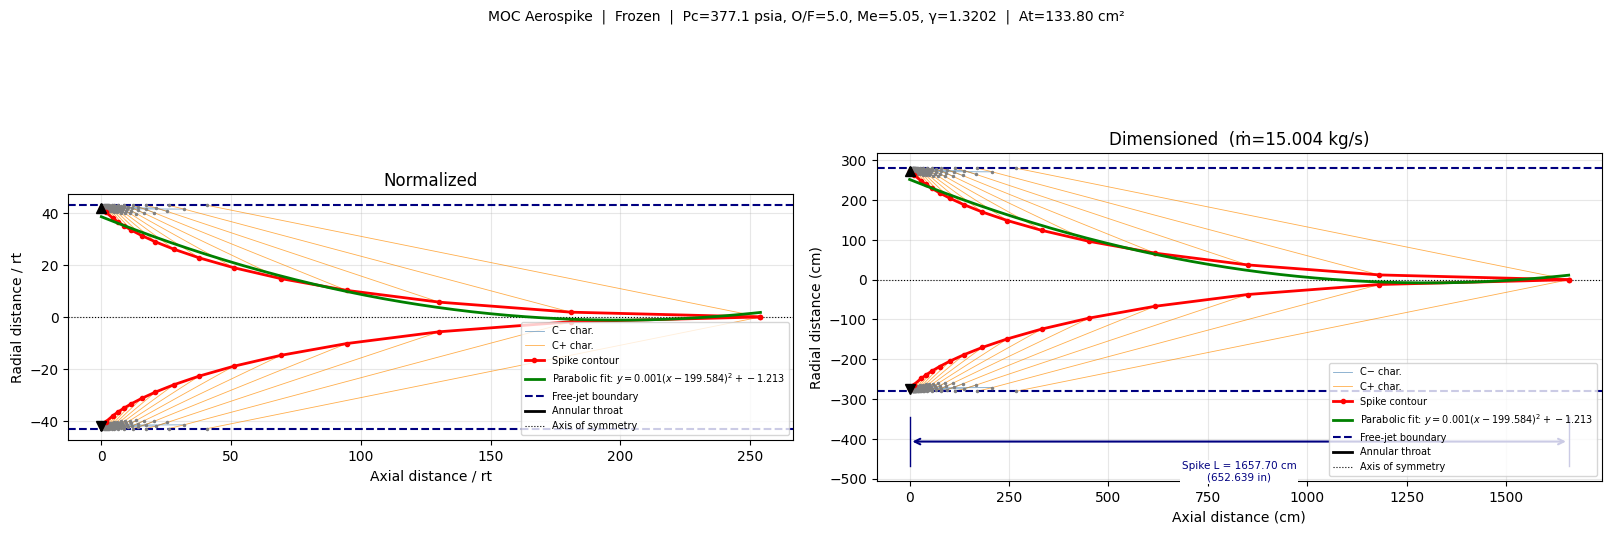

In [9]:
"""
MOC Aerospike Nozzle Contour — driven by NASA CEA output
---------------------------------------------------------
Reads gamma, Mach exit, C*, Pc, and Ae/At directly from your CEA file
via parse_blocks(), then computes and plots the aerospike spike contour via
Method of Characteristics, including C+ and C- characteristic lines.
Parabolic wall fit: y(x) = a*(x - b)^2 + c  via scipy curve_fit.

This is the Aerospike MOC for finding the contour of the nozzle.
The same equations apply just inverted so that the nozzle "wall"
runs towards itself and not away from itself.
The tip of the aerospike ends at the centerline of the conventional nozzle.
The base of the nozzle starts at the radial distance where the conventional
one would normally end. What is known as the free-jet boundary replaces
the outer wall.

The aerospike is the "flipped" version of the conventional nozzle:
  - The throat is at the OUTER radius (annular throat at top)
  - The spike wall is at the BOTTOM (centerline of the conventional nozzle)
  - Flow expands radially INWARD/downward along the spike surface
  - The free-jet boundary replaces the outer nozzle wall
"""

import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar, curve_fit

# ================================================================
#  USER SETTINGS
# ================================================================
FILE       = "CEA(30km)F.txt"   # your CEA output filename
ASSUMPTION = "frozen"          # "equilibrium" or "frozen"
AT_KNOWN   = 0.01338           # m²  — physical throat area (e.g. 20.75 in² = 0.01338 m²)
                               #        not in CEA output, must be provided here
NUM_LINES  = 15                # MOC resolution (more = smoother, try 10–50)
# ================================================================


# ------------------------------------------------------------------
# 1. Parse CEA file  (from cea_extractor.py)
# ------------------------------------------------------------------
def parse_blocks(filepath):
    with open(filepath, 'r') as f:
        content = f.read()

    blocks = re.split(r'(?=THEORETICAL ROCKET PERFORMANCE)', content)
    results = []

    for block in blocks:
        if 'THEORETICAL ROCKET PERFORMANCE' not in block:
            continue

        assumption = ('Equilibrium' if 'EQUILIBRIUM' in block
                      else 'Frozen' if 'FROZEN' in block else 'Unknown')

        def get_row(label):
            """Return list of floats for a data row, handling sci notation like 7.2388-2."""
            pattern = rf'{re.escape(label)}\s+([\d.E+\-]+(?:\s+[\d.E+\-]+)*)'
            m = re.search(pattern, block)
            if not m:
                return None
            raw = re.sub(r'(\d)([\+\-])(\d)', r'\1E\2\3', m.group(1))
            return [float(x) for x in raw.split()]

        # O/F
        of_m = re.search(r'O/F=\s*([\d.]+)', block)
        of   = float(of_m.group(1)) if of_m else None

        # Pc in PSIA
        pc_psia_m = re.search(r'Pin\s*=\s*([\d.]+)\s*PSIA', block)
        pc_psia   = float(pc_psia_m.group(1)) if pc_psia_m else None

        # Performance parameters block
        perf_block = re.search(r'PERFORMANCE PARAMETERS.*?(?=MASS FRACTIONS)', block, re.DOTALL)
        pb = perf_block.group(0) if perf_block else ''

        # Ae/At (throat=1.0, exit=second value)
        aeat_m = re.search(r'Ae/At\s+([\d.]+)\s+([\d.]+)', pb)
        ae_at  = float(aeat_m.group(2)) if aeat_m else None

        # C*
        cstar_m = re.search(r'CSTAR,\s*M/SEC\s+([\d.]+)', pb)
        cstar   = float(cstar_m.group(1)) if cstar_m else None

        # Isp at exit (second value)
        isp_m    = re.search(r'Isp,\s*M/SEC\s+([\d.]+)\s+([\d.]+)', pb)
        isp_exit = float(isp_m.group(2)) if isp_m else None

        # Column rows: [CHAMBER, THROAT, EXIT]
        gamma_row = get_row('GAMMAs')
        mach_row  = get_row('MACH NUMBER')
        son_row   = get_row('SON VEL,M/SEC')

        gamma_exit = gamma_row[2] if gamma_row and len(gamma_row) > 2 else None
        mach_exit  = mach_row[2]  if mach_row  and len(mach_row)  > 2 else None
        vel_exit   = (son_row[2] * mach_exit
                      if son_row and mach_exit and len(son_row) > 2 else None)

        results.append({
            'assumption': assumption,
            'pc_psia':    pc_psia,
            'of':         of,
            'cstar':      cstar,
            'gamma_exit': gamma_exit,
            'mach_exit':  mach_exit,
            'vel_exit':   vel_exit,
            'ae_at':      ae_at,
            'isp_exit':   isp_exit,
        })

    return results


def select_block(results, assumption):
    """Return the result block matching the requested assumption."""
    target = assumption.strip().capitalize()
    for r in results:
        if r['assumption'].capitalize() == target:
            return r
    return None


# ------------------------------------------------------------------
# 2. Prandtl-Meyer functions
# ------------------------------------------------------------------
def prandtl_meyer(mach, gamma):
    return (
        np.sqrt((gamma + 1.) / (gamma - 1.)) *
        np.arctan(np.sqrt((gamma - 1.) * (mach**2 - 1.) / (gamma + 1.))) -
        np.arctan(np.sqrt(mach**2 - 1.))
    )

def solve_pm(mach, nu, gamma):
    return nu - prandtl_meyer(mach, gamma)


# ------------------------------------------------------------------
# 3. Parabola model  y(x) = a*(x - b)^2 + c
# ------------------------------------------------------------------
def parabola(x, a, b, c):
    return a * np.power(x - b, 2) + c


# ------------------------------------------------------------------
# 4. MOC kernel — same math as conventional, connectivity identical
# ------------------------------------------------------------------
def compute_moc(gamma, mach_exit, num_lines):
    angle_max = 0.5 * prandtl_meyer(mach_exit, gamma)

    idk_count = num_lines
    for idx in range(1, num_lines):
        for idy in range(idx, num_lines):
            idk_count += 1
        idk_count += 1
    num_points = idk_count + 1

    nus    = np.zeros(num_points)
    thetas = np.zeros(num_points)
    machs  = np.zeros(num_points)
    mus    = np.zeros(num_points)
    y      = np.zeros(num_points)
    x      = np.zeros(num_points)

    constant_minus = np.zeros(num_lines)
    constant_plus  = np.zeros(num_lines)

    c_minus_lines = []
    c_plus_lines  = []

    # ---- Initial expansion fan ----
    delta_theta0 = angle_max / num_lines
    nus[0]    = delta_theta0
    thetas[0] = delta_theta0
    sol = root_scalar(solve_pm, x0=1.1, bracket=[1.000001, 20], args=(nus[0], gamma))
    machs[0]  = sol.root
    mus[0]    = np.arcsin(1. / machs[0])
    constant_minus[0] = thetas[0] + nus[0]
    constant_plus[0]  = thetas[0] - nus[0]
    x[0] = -1. / np.tan(0.5*thetas[0] - 0.5*(np.pi/2. + mus[0]))
    y[0] = 0.

    delta_theta = (angle_max - delta_theta0) / (num_lines - 1)
    for idx in range(1, num_lines):
        thetas[idx] = thetas[idx-1] + delta_theta
        nus[idx]    = thetas[idx]
        sol = root_scalar(solve_pm, x0=1.1, bracket=[1.00001, 20], args=(nus[idx], gamma))
        machs[idx]  = sol.root
        mus[idx]    = np.arcsin(1. / machs[idx])
        constant_minus[idx] = thetas[idx] + nus[idx]

        dydx_p = np.tan(0.5*(thetas[idx-1]+thetas[idx]) + 0.5*(mus[idx-1]+mus[idx]))
        dydx_m = np.tan(thetas[idx] - mus[idx])
        y[idx]  = (dydx_p*(-1./dydx_m - x[idx-1]) + y[idx-1]) / (1 - dydx_p/dydx_m)
        x[idx]  = (y[idx] - 1.) / dydx_m

    # ---- Upper surface point ----
    idx = num_lines
    thetas[idx] = thetas[idx-1]
    nus[idx]    = nus[idx-1]
    machs[idx]  = machs[idx-1]
    mus[idx]    = mus[idx-1]
    dydx_m = np.tan(0.5*(angle_max + thetas[idx]))
    dydx_p = np.tan(0.5*(thetas[idx-1]+thetas[idx]) + 0.5*(mus[idx-1]+mus[idx]))
    y[idx]  = (dydx_p*(-x[idx-1] - 1./dydx_m) + y[idx-1]) / (1. - dydx_p/dydx_m)
    x[idx]  = (y[idx] - 1) / dydx_m

    # ---- Remaining characteristic lines ----
    idk = num_lines
    for idx in range(1, num_lines):
        c_minus = [idx]
        c_plus  = []

        for idy in range(idx, num_lines):
            idk += 1
            if idy == idx:
                thetas[idk] = 0
                nus[idk]    = constant_minus[idx]
                constant_plus[idx] = thetas[idk] - nus[idk]
                c_plus.append(idk)
            else:
                thetas[idk] = 0.5*(constant_minus[idy] + constant_plus[idx])
                nus[idk]    = 0.5*(constant_minus[idy] - constant_plus[idx])
                c_minus.append(idk)
                c_plus.append(idk)

            sol = root_scalar(solve_pm, x0=1.1, bracket=[1.0001, 20], args=(nus[idk], gamma))
            machs[idk] = sol.root
            mus[idk]   = np.arcsin(1. / machs[idk])

            idk_prev = idk - (num_lines - idx + 1)
            if idy == idx:
                y[idk] = 0.
                x[idk] = x[idk_prev] - y[idk_prev] / np.tan(thetas[idk_prev] - mus[idk_prev])
            else:
                dydx_p = np.tan(0.5*(thetas[idk-1]+thetas[idk]) + 0.5*(mus[idk-1]+mus[idk]))
                dydx_m = np.tan(0.5*(thetas[idk]+thetas[idk_prev]) - 0.5*(mus[idk]+mus[idk_prev]))
                y[idk] = (dydx_p*(-y[idk_prev]/dydx_m + x[idk_prev] - x[idk-1]) + y[idk-1]) / (1. - dydx_p/dydx_m)
                x[idk] = x[idk_prev] + (y[idk] - y[idk_prev]) / dydx_m

        # Wall point
        idk += 1
        thetas[idk] = thetas[idk-1]
        nus[idk]    = nus[idk-1]
        machs[idk]  = machs[idk-1]
        mus[idk]    = mus[idk-1]

        idk_prev = idk - (num_lines - idx + 1)
        dydx_m = np.tan(0.5*(thetas[idk_prev] + thetas[idk]))
        dydx_p = np.tan(0.5*(thetas[idk-1]+thetas[idk]) + 0.5*(mus[idk-1]+mus[idk]))
        y[idk] = (dydx_p*(-y[idk_prev]/dydx_m + x[idk_prev] - x[idk-1]) + y[idk-1]) / (1. - dydx_p/dydx_m)
        x[idk] = x[idk_prev] + (y[idk] - y[idk_prev]) / dydx_m

        c_plus.append(idk)
        c_minus_lines.append(c_minus)
        c_plus_lines.append(c_plus)

    return x, y, machs, c_minus_lines, c_plus_lines


# ------------------------------------------------------------------
# 5. Extract wall (spike) contour
# ------------------------------------------------------------------
def extract_wall(x, y, num_lines):
    wall_x = [0.0]
    wall_y = [1.0]
    idk = num_lines
    wall_x.append(x[idk])
    wall_y.append(y[idk])
    for idx in range(1, num_lines):
        for idy in range(idx, num_lines):
            idk += 1
        idk += 1
        wall_x.append(x[idk])
        wall_y.append(y[idk])
    return np.array(wall_x), np.array(wall_y)


# ------------------------------------------------------------------
# 6. Flip coordinates for aerospike:
#    Conventional:  throat at y=1 (top wall), centerline at y=0
#    Aerospike:     throat at r=rt (outer annulus), spike tip at r=0
#
#    Flip:  y_spike = y_max - y_conv  (invert radial axis)
#           x_spike = x_conv          (axial stays the same)
#
#    This maps:
#      conventional wall  (y = high)  → spike tip  (r = low)
#      conventional centerline (y=0)  → free-jet boundary (r = high)
# ------------------------------------------------------------------
def flip_to_aerospike(x, y, y_max):
    return x.copy(), y_max - y


# ------------------------------------------------------------------
# 7. Main
# ------------------------------------------------------------------
def main():
    print(f"\nReading: {FILE}  [{ASSUMPTION}]\n")
    results = parse_blocks(FILE)

    if not results:
        print(f"ERROR: No blocks found in {FILE}. Check your filename.")
        return

    cea = select_block(results, ASSUMPTION)
    if cea is None:
        found = [r['assumption'] for r in results]
        print(f"ERROR: Could not find '{ASSUMPTION}' block. Found: {found}")
        return

    # --- Pull all values from CEA output ---
    gamma     = cea['gamma_exit']
    mach_exit = cea['mach_exit']
    cstar     = cea['cstar']
    pc_psia   = cea['pc_psia']
    ae_at_cea = cea['ae_at']

    # --- Derive remaining quantities from CEA values + AT_KNOWN ---
    pc_pa = pc_psia * 6894.76                   # Pa
    mdot  = (AT_KNOWN * pc_pa) / cstar          # kg/s  from At·Pc/C*
    rt    = np.sqrt(AT_KNOWN / np.pi)           # m
    ae_m2 = AT_KNOWN * ae_at_cea                # m²

    print(f"  CEA values used:")
    print(f"    Pc        = {pc_psia} PSIA  ({pc_pa:.0f} Pa)")
    print(f"    O/F       = {cea['of']}")
    print(f"    C*        = {cstar:.2f} m/s")
    print(f"    Isp       = {cea['isp_exit']:.2f} m/s")
    print(f"    Gamma     = {gamma:.4f}  (exit)")
    print(f"    Mach exit = {mach_exit:.3f}")
    print(f"    Ae/At     = {ae_at_cea:.4f}  (from CEA)")

    print(f"\n  Geometry (At = {AT_KNOWN} m²):")
    print(f"    MDOT = {mdot:.4f} kg/s")
    print(f"    At   = {AT_KNOWN*1e4:.4f} cm²   rt = {rt*100:.4f} cm  ({rt*100/2.54:.4f} in)")
    print(f"    Ae   = {ae_m2*1e4:.4f} cm²   re = {np.sqrt(ae_m2/np.pi)*100:.4f} cm")

    print(f"\n  Running MOC ({NUM_LINES} lines)...")
    x_norm, y_norm, machs, c_minus_lines, c_plus_lines = \
        compute_moc(gamma, mach_exit, NUM_LINES)

    y_max_norm = y_norm.max()

    # --- Normalized aerospike coords ---
    xa_norm, ya_norm   = flip_to_aerospike(x_norm, y_norm, y_max_norm)
    wall_xn, wall_yn   = extract_wall(x_norm, y_norm, NUM_LINES)
    spike_xn, spike_yn = flip_to_aerospike(wall_xn, wall_yn, y_max_norm)
    freejet_yn_norm    = y_max_norm

    # --- Scale to real dimensions (cm) ---
    scale_cm   = rt * 100
    xa_real    = xa_norm  * scale_cm
    ya_real    = ya_norm  * scale_cm
    spike_xr   = spike_xn * scale_cm
    spike_yr   = spike_yn * scale_cm
    freejet_yr = freejet_yn_norm * scale_cm

    # --- Parabolic fit on spike contour ---
    popt_n, _ = curve_fit(parabola, spike_xn, spike_yn,
                          p0=[0.1, spike_xn[-1], spike_yn[-1]])
    a_n, b_n, c_n = popt_n

    xfit_n = np.linspace(0, np.max(spike_xn), 300)
    yfit_n = parabola(xfit_n, *popt_n)

    a_r = a_n / scale_cm
    b_r = b_n * scale_cm
    c_r = c_n * scale_cm

    xfit_r = xfit_n * scale_cm
    yfit_r = yfit_n * scale_cm

    print(f"\n  Parabolic spike fit  y(x) = a·(x − b)² + c")
    print(f"  Normalised (/rt):")
    print(f"    y(x) = {a_n:.4f}·(x − {b_n:.4f})² + {c_n:.4f}")
    print(f"  Dimensioned (cm):")
    print(f"    y(x) = {a_r:.4f}·(x − {b_r:.4f})² + {c_r:.4f}")

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), layout='constrained')
    fig.suptitle(
        f'MOC Aerospike  |  {ASSUMPTION.capitalize()}  |  '
        f'Pc={pc_psia} psia, O/F={cea["of"]}, Me={mach_exit:.2f}, γ={gamma:.4f}  |  '
        f'At={AT_KNOWN*1e4:.2f} cm²',
        fontsize=10
    )

    plot_configs = [
        (axes[0], xa_norm, ya_norm, spike_xn, spike_yn, xfit_n, yfit_n,
         freejet_yn_norm, 1.0, 'Axial distance / rt', 'Normalized'),
        (axes[1], xa_real, ya_real, spike_xr, spike_yr, xfit_r, yfit_r,
         freejet_yr, scale_cm, 'Axial distance (cm)',
         f'Dimensioned  (ṁ={mdot:.3f} kg/s)'),
    ]

    for ax, xd, yd, sxd, syd, xfd, yfd, fj_y, sc, xlabel, title in plot_configs:
        is_dim = (sc != 1.0)

        # C- characteristic lines
        for i, line in enumerate(c_minus_lines):
            lx = [xd[j] for j in line]
            ly = [yd[j] for j in line]
            ax.plot(lx,  ly, '-', color='steelblue', lw=0.6, alpha=0.7,
                    label='C− char.' if i == 0 else '')
            ax.plot(lx, [-v for v in ly], '-', color='steelblue', lw=0.6, alpha=0.7)

        # C+ characteristic lines
        for i, line in enumerate(c_plus_lines):
            lx = [xd[j] for j in line]
            ly = [yd[j] for j in line]
            ax.plot(lx,  ly, '-', color='darkorange', lw=0.6, alpha=0.7,
                    label='C+ char.' if i == 0 else '')
            ax.plot(lx, [-v for v in ly], '-', color='darkorange', lw=0.6, alpha=0.7)

        # Interior field points
        ax.plot(xd,  yd, 'o', ms=1.5, color='gray', zorder=3)
        ax.plot(xd, -yd, 'o', ms=1.5, color='gray', zorder=3)

        # Spike contour
        ax.plot(sxd,  syd, 'r-o', ms=3, lw=2, zorder=5, label='Spike contour')
        ax.plot(sxd, -syd, 'r-o', ms=3, lw=2, zorder=5)

        # Parabolic fit overlay
        ax.plot(xfd,  yfd, 'g-', lw=2, zorder=6,
                label=fr'Parabolic fit: $y={a_n:.3f}(x-{b_n:.3f})^2+{c_n:.3f}$')

        # Free-jet boundary
        ax.axhline( fj_y, color='navy', lw=1.5, linestyle='--', label='Free-jet boundary')
        ax.axhline(-fj_y, color='navy', lw=1.5, linestyle='--')

        # Annular throat at x=0
        ax.plot([0, 0], [ syd[0],  fj_y], 'k-', lw=2, zorder=6, label='Annular throat')
        ax.plot([0, 0], [-syd[0], -fj_y], 'k-', lw=2, zorder=6)
        ax.plot(0,  syd[0], 'k^', ms=7, zorder=7)
        ax.plot(0, -syd[0], 'kv', ms=7, zorder=7)

        # Axis of symmetry
        ax.axhline(0, color='k', lw=0.8, linestyle=':', label='Axis of symmetry')

        # Dimension annotation on dimensioned plot
        if is_dim:
            spike_len   = spike_xr[-1]
            annot_y_bot = -fj_y * 1.45

            ax.annotate(
                '', xy=(spike_len, annot_y_bot), xytext=(0, annot_y_bot),
                arrowprops=dict(arrowstyle='<->', color='navy', lw=1.5)
            )
            ax.text(
                spike_len / 2, annot_y_bot * 1.12,
                f'Spike L = {spike_len:.2f} cm\n({spike_len/2.54:.3f} in)',
                ha='center', va='top', fontsize=7.5, color='navy',
                bbox=dict(fc='white', ec='none', pad=1)
            )
            ax.plot([0,         0        ], [annot_y_bot*0.85, annot_y_bot*1.15],
                    color='navy', lw=1)
            ax.plot([spike_len, spike_len], [annot_y_bot*0.85, annot_y_bot*1.15],
                    color='navy', lw=1)

        ax.set_xlabel(xlabel)
        ax.set_ylabel('Radial distance' + (' / rt' if not is_dim else ' (cm)'))
        ax.set_title(title)
        ax.set_aspect('equal', 'box')
        ax.legend(fontsize=7, loc='lower right')
        ax.grid(True, alpha=0.3)

    plt.show()


if __name__ == '__main__':
    main()

  NOZZLE THRUST COEFFICIENT (C_F) INTEGRATION ANALYSIS

  CEA values used (frozen):
    gamma (γ)          = 1.3668
    Pc                 = 2.6000 MPa  (377.1 PSIA)
    Pe_bell (fixed)    = 52.44 Pa
    Ae/At              = 1999.3800
    O/F                = 5.0
    C*                 = 2318.60 m/s
    Isp                = 4570.60 m/s
    At                 = 0.01338 m²
    MDOT               = 15.0040 kg/s
    Altitude range     = 0 – 60 km
    Integration steps  = 5000

  Altitude (km)    Pa (kPa)       CF_bell        CF_spike      
  ----------------------------------------------------------
  0.0              101.325        -76.07525      1.41351       
  6.7              43.034         -31.25044      1.51438       
  13.3             15.691         -10.22395      1.60141       
  20.0             5.478          -2.37028       1.66705       
  26.7             2.290          0.08124        1.70771       
  33.3             1.631          0.58834        1.72093       
  40.0       

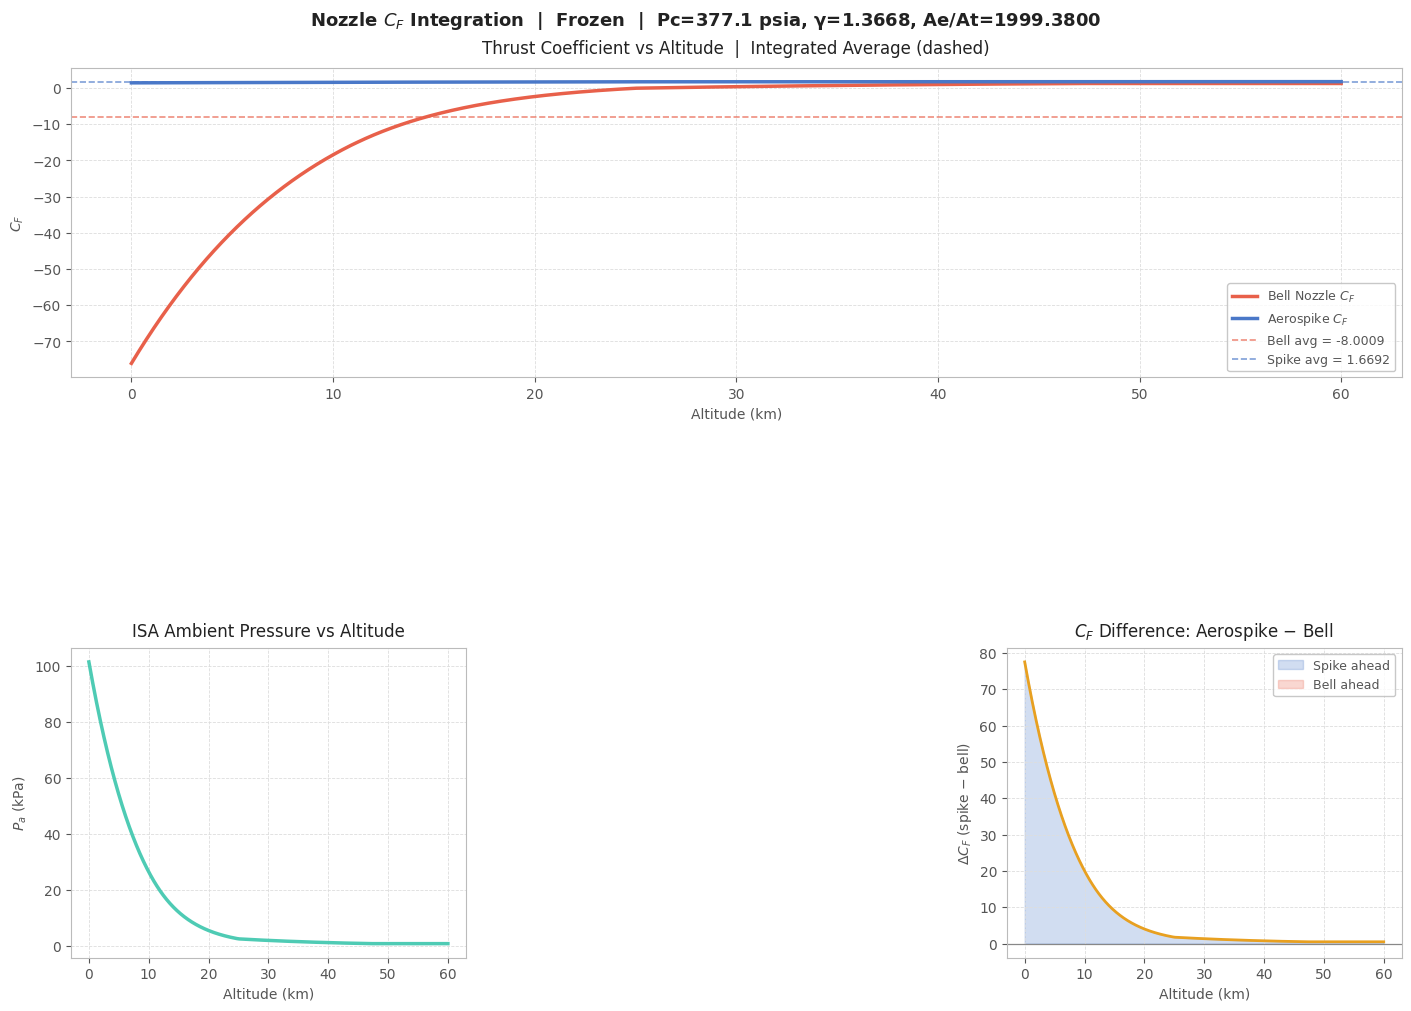

In [10]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ================================================================
FILE       = "CEA(60km)F.txt"
ASSUMPTION = "frozen"
AT_KNOWN   = 0.01338       # m²  — physical throat area, not in CEA output
H_START    =     0         # m
H_END      = 60000         # m
N_STEPS    =  5000
# ================================================================


# ------------------------------------------------------------------
# CEA Parser
# ------------------------------------------------------------------
def parse_blocks(filepath):
    with open(filepath, 'r') as f:
        content = f.read()

    results = []
    for block in re.split(r'(?=THEORETICAL ROCKET PERFORMANCE)', content):
        if 'THEORETICAL ROCKET PERFORMANCE' not in block:
            continue

        assumption = ('Equilibrium' if 'EQUILIBRIUM' in block
                      else 'Frozen' if 'FROZEN' in block else 'Unknown')

        def get_row(label):
            m = re.search(rf'{re.escape(label)}\s+([\d.E+\-]+(?:\s+[\d.E+\-]+)*)', block)
            if not m:
                return None
            raw = re.sub(r'(\d)([\+\-])(\d)', r'\1E\2\3', m.group(1))
            return [float(x) for x in raw.split()]

        of_m      = re.search(r'O/F=\s*([\d.]+)', block)
        pc_psia_m = re.search(r'Pin\s*=\s*([\d.]+)\s*PSIA', block)
        perf      = re.search(r'PERFORMANCE PARAMETERS.*?(?=MASS FRACTIONS)', block, re.DOTALL)
        pb        = perf.group(0) if perf else ''
        aeat_m    = re.search(r'Ae/At\s+([\d.]+)\s+([\d.]+)', pb)
        cstar_m   = re.search(r'CSTAR,\s*M/SEC\s+([\d.]+)', pb)
        isp_m     = re.search(r'Isp,\s*M/SEC\s+([\d.]+)\s+([\d.]+)', pb)

        gamma_row = get_row('GAMMAs')
        mach_row  = get_row('MACH NUMBER')
        son_row   = get_row('SON VEL,M/SEC')
        prat_row  = get_row('P/P1')          # [chamber, throat, exit] pressure ratios
        mach_exit = mach_row[2] if mach_row and len(mach_row) > 2 else None

        results.append({
            'assumption': assumption,
            'of':         float(of_m.group(1)) if of_m else None,
            'pc_psia':    float(pc_psia_m.group(1)) if pc_psia_m else None,
            'cstar':      float(cstar_m.group(1)) if cstar_m else None,
            'ae_at':      float(aeat_m.group(2)) if aeat_m else None,
            'isp_exit':   float(isp_m.group(2)) if isp_m else None,
            'gamma_exit': gamma_row[2] if gamma_row and len(gamma_row) > 2 else None,
            'mach_exit':  mach_exit,
            'vel_exit':   son_row[2] * mach_exit if son_row and mach_exit and len(son_row) > 2 else None,
            'pe_over_pc': prat_row[2] if prat_row and len(prat_row) > 2 else None,
        })

    return results


def select_block(results, assumption):
    target = assumption.strip().capitalize()
    for r in results:
        if r['assumption'].capitalize() == target:
            return r
    return None


# ------------------------------------------------------------------
# ISA Atmosphere (troposphere - stratosphere) 
# ------------------------------------------------------------------
def isa_pressure(h):
    h  = np.clip(np.asarray(h, dtype=float), 0, 47000)
    return np.where(
        h <= 11000,
        101325.0 * np.clip(1.0 - h / 44_307.7, 0, None) ** 5.2561,
        np.where(
            h <= 25000,
            22632.0 * np.exp(-(h - 11000) / 6_341.6),
            2488.0  * np.clip(1.0 - (h - 25_000) / 228812.0, 0, None) ** 11.388
        )
    )


# ------------------------------------------------------------------
# Thrust Coefficient Functions
# ------------------------------------------------------------------
def momentum_term_base(gamma):
    return np.sqrt(
        (2.0 * gamma**2) / (gamma - 1.0) *
        (2.0 / (gamma + 1.0)) ** ((gamma + 1.0) / (gamma - 1.0))
    )


def cf_bell(Pa, gamma, Pc, Pe, Ae_At):
    base     = momentum_term_base(gamma)
    mom_term = base * np.sqrt(1.0 - (Pe / Pc) ** ((gamma - 1.0) / gamma))
    prs_term = (Ae_At / Pc) * (Pe - Pa)
    return mom_term + prs_term


def cf_aerospike(Pa, gamma, Pc):
    base = momentum_term_base(gamma)
    return base * np.sqrt(np.clip(1.0 - (Pa / Pc) ** ((gamma - 1.0) / gamma), 0, None))


# ------------------------------------------------------------------
# Numerical Integration
# ------------------------------------------------------------------
def integrate_cf(cf_array, h_array):
    return np.trapezoid(cf_array, h_array) / (h_array[-1] - h_array[0])


# ------------------------------------------------------------------
# Main
# ------------------------------------------------------------------
def main():
    print("=" * 65)
    print("  NOZZLE THRUST COEFFICIENT (C_F) INTEGRATION ANALYSIS")
    print("=" * 65)

    results = parse_blocks(FILE)
    if not results:
        print(f"ERROR: No blocks found in {FILE}.")
        return

    cea = select_block(results, ASSUMPTION)
    if cea is None:
        print(f"ERROR: '{ASSUMPTION}' block not found. Found: {[r['assumption'] for r in results]}")
        return

    # --- Pull all values from CEA ---
    gamma  = cea['gamma_exit']
    pc_pa  = cea['pc_psia'] * 6894.76
    ae_at  = cea['ae_at']

    # Pe from CEA pressure ratio P/P1 (exit / chamber)
    # CEA reports P/P1 where P1 = Pc, so Pe = Pc * (P/P1)_exit
    if cea['pe_over_pc'] is not None:
        pe_bell = pc_pa * cea['pe_over_pc']
    else:
        # fallback: isentropic Pe from exit Mach
        me = cea['mach_exit']
        pe_bell = pc_pa * (1.0 + 0.5*(gamma - 1.0)*me**2) ** (-gamma / (gamma - 1.0))

    mdot = (AT_KNOWN * pc_pa) / cea['cstar']

    print(f"\n  CEA values used ({ASSUMPTION}):")
    print(f"    gamma (γ)          = {gamma:.4f}")
    print(f"    Pc                 = {pc_pa/1e6:.4f} MPa  ({cea['pc_psia']} PSIA)")
    print(f"    Pe_bell (fixed)    = {pe_bell:.2f} Pa")
    print(f"    Ae/At              = {ae_at:.4f}")
    print(f"    O/F                = {cea['of']}")
    print(f"    C*                 = {cea['cstar']:.2f} m/s")
    print(f"    Isp                = {cea['isp_exit']:.2f} m/s")
    print(f"    At                 = {AT_KNOWN} m²")
    print(f"    MDOT               = {mdot:.4f} kg/s")
    print(f"    Altitude range     = {H_START/1000:.0f} – {H_END/1000:.0f} km")
    print(f"    Integration steps  = {N_STEPS}")

    # --- Altitude and pressure arrays ---
    h  = np.linspace(H_START, H_END, N_STEPS)
    Pa = isa_pressure(h)

    # --- C_F arrays ---
    CF_bell  = cf_bell(Pa, gamma, pc_pa, pe_bell, ae_at)
    CF_spike = cf_aerospike(Pa, gamma, pc_pa)

    # --- Integrated averages ---
    CF_bell_avg  = integrate_cf(CF_bell,  h)
    CF_spike_avg = integrate_cf(CF_spike, h)
    advantage_pct = (CF_spike_avg / CF_bell_avg - 1.0) * 100.0

    THRUST_BELL  = CF_bell_avg  * pc_pa * AT_KNOWN
    THRUST_SPIKE = CF_spike_avg * pc_pa * AT_KNOWN

    # --- Sample table ---
    print(f"\n  {'Altitude (km)':<16} {'Pa (kPa)':<14} {'CF_bell':<14} {'CF_spike':<14}")
    print(f"  {'-'*58}")
    for idx in np.linspace(0, N_STEPS - 1, 10, dtype=int):
        print(f"  {h[idx]/1000:<16.1f} {Pa[idx]/1000:<14.3f} "
              f"{CF_bell[idx]:<14.5f} {CF_spike[idx]:<14.5f}")

    print(f"\n  Integrated Results (trapezoid rule, {H_START/1000:.0f}–{H_END/1000:.0f} km):")
    print(f"    Bell  C̄_F  = {CF_bell_avg:.5f}")
    print(f"    Spike C̄_F  = {CF_spike_avg:.5f}")
    print(f"    Aerospike advantage = {advantage_pct:+.2f}%")
    print(f"    Spike Thrust (avg)  = {THRUST_SPIKE/1000:.5f} kN")
    print(f"    Bell  Thrust (avg)  = {THRUST_BELL/1000:.5f} kN")

    # --- Term breakdown at key altitudes ---
    base = momentum_term_base(gamma)
    mom  = base * np.sqrt(1.0 - (pe_bell / pc_pa) ** ((gamma - 1.0) / gamma))

    print(f"\n  Term Breakdown:")
    print(f"  {'Altitude (km)':<12} {'Pa (kPa)':<12} {'Bell mom':<12} {'Bell prs':<12} "
          f"{'Bell CF':<12} {'Spike CF':<12}")
    print(f"  {'-'*72}")
    for h_km in [0, 10, 20, 30, 40, 50, 60]:
        h_m = h_km * 1000
        if h_m > H_END:
            continue
        pa  = float(isa_pressure(np.array([h_m]))[0])
        prs = (ae_at / pc_pa) * (pe_bell - pa)
        spk = float(cf_aerospike(np.array([pa]), gamma, pc_pa)[0])
        print(f"  {h_km:<12} {pa/1000:<12.3f} {mom:<12.5f} {prs:<12.5f} "
              f"{mom+prs:<12.5f} {spk:<12.5f}")

    # ----------------------------------------------------------------
    # Plotting
    # ----------------------------------------------------------------
    LAB_ORANGE = "#E8A020"
    LAB_RED    = "#E8604A"
    LAB_BLUE   = "#4A78C8"
    LAB_TEAL   = "#4ECBB4"
    LAB_ORANGE = "#E8A020"
    LAB_GREY   = "#888888"
    PANEL      = "#FFFFFF"
    GRID_C     = "#DDDDDD"
    SPINE_C    = "#BBBBBB"
    TEXT_C     = "#222222"
    SUBTEXT_C  = "#555555"

    fig = plt.figure(figsize=(14, 10), layout="constrained")
    fig.patch.set_facecolor(PANEL)
    gs   = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
    h_km = h / 1000

    ax1 = fig.add_subplot(gs[0, :], facecolor=PANEL)
    ax1.plot(h_km, CF_bell,  color=LAB_RED,  lw=2.5, label="Bell Nozzle $C_F$")
    ax1.plot(h_km, CF_spike, color=LAB_BLUE, lw=2.5, label="Aerospike $C_F$")
    ax1.axhline(CF_bell_avg,  color=LAB_RED,  lw=1.2, ls="--", alpha=0.7, label=f"Bell avg = {CF_bell_avg:.4f}")
    ax1.axhline(CF_spike_avg, color=LAB_BLUE, lw=1.2, ls="--", alpha=0.7, label=f"Spike avg = {CF_spike_avg:.4f}")
    ax1.set_xlabel("Altitude (km)", color=SUBTEXT_C)
    ax1.set_ylabel("$C_F$",         color=SUBTEXT_C)
    ax1.set_title("Thrust Coefficient vs Altitude  |  Integrated Average (dashed)", color=TEXT_C, pad=10)
    ax1.tick_params(colors=SUBTEXT_C)
    ax1.spines[:].set_color(SPINE_C)
    ax1.legend(facecolor=PANEL, edgecolor=SPINE_C, labelcolor=SUBTEXT_C, fontsize=9)
    ax1.grid(color=GRID_C, linestyle="--", linewidth=0.6)

    ax2 = fig.add_subplot(gs[1, 0], facecolor=PANEL)
    ax2.plot(h_km, Pa / 1000, color=LAB_TEAL, lw=2.5)
    ax2.set_xlabel("Altitude (km)", color=SUBTEXT_C)
    ax2.set_ylabel("$P_a$ (kPa)",   color=SUBTEXT_C)
    ax2.set_title("ISA Ambient Pressure vs Altitude", color=TEXT_C, pad=8)
    ax2.tick_params(colors=SUBTEXT_C)
    ax2.spines[:].set_color(SPINE_C)
    ax2.grid(color=GRID_C, linestyle="--", linewidth=0.6)

    ax3 = fig.add_subplot(gs[1, 1], facecolor=PANEL)
    delta = CF_spike - CF_bell
    ax3.fill_between(h_km, delta, 0, where=(delta > 0), color=LAB_BLUE,   alpha=0.25, label="Spike ahead")
    ax3.fill_between(h_km, delta, 0, where=(delta < 0), color=LAB_RED,    alpha=0.25, label="Bell ahead")
    ax3.plot(h_km, delta, color=LAB_ORANGE, lw=2)
    ax3.axhline(0, color=LAB_GREY, lw=0.9)
    ax3.set_xlabel("Altitude (km)",                color=SUBTEXT_C)
    ax3.set_ylabel("$\\Delta C_F$ (spike − bell)", color=SUBTEXT_C)
    ax3.set_title("$C_F$ Difference: Aerospike − Bell", color=TEXT_C, pad=8)
    ax3.tick_params(colors=SUBTEXT_C)
    ax3.spines[:].set_color(SPINE_C)
    ax3.legend(facecolor=PANEL, edgecolor=SPINE_C, labelcolor=SUBTEXT_C, fontsize=9)
    ax3.grid(color=GRID_C, linestyle="--", linewidth=0.6)

    fig.suptitle(
        f"Nozzle $C_F$ Integration  |  {ASSUMPTION.capitalize()}  |  "
        f"Pc={cea['pc_psia']} psia, γ={gamma:.4f}, Ae/At={ae_at:.4f}",
        color=TEXT_C, fontsize=13, fontweight="bold"
    )
    plt.show()


if __name__ == "__main__":
    main()